# EDA — Meteo AEMET Histórico

**TFM Smart Air Madrid** · rama `EVA/EDA_TIEMPO`

Análisis exploratorio de `meteo_aemet_historico.parquet`, la tabla normalizada de observaciones
diarias de AEMET para las estaciones de Madrid entre 2020 y 2024.

La tabla está en **formato largo**: cada fila es una combinación de *estación + fecha +
variable*, con el dato en `valor` y su unidad en `uom`. Eso cambia cómo se busca un nulo: aquí
un dato que falta no aparece como `NaN`, sino que **la fila directamente no existe**. Por eso la
sección 2 no cuenta nulos, sino que compara lo que hay contra el calendario completo.

**Objetivo:** cerrar las decisiones de tratamiento de nulos, atípicos y variables, y dejarlas
escritas como una lista de instrucciones ejecutable para el equipo de normalización. El
resultado final es la lista de instrucciones de la sección 8.

**Cómo ejecutarlo:** el notebook está sin ejecutar. Colócalo junto al parquet y usa
*Kernel → Restart & Run All*, de arriba abajo y sin saltarse celdas: varias secciones dependen
de objetos creados en las anteriores.

---

## Índice

| Sección | Contenido |
|---|---|
| **1** | Carga, dimensión de estaciones, validaciones de integridad y convenio temporal de las variables |
| **2** | Huecos: dónde están, cuánto pesan y de dónde vienen (incluido el rastreo de los códigos `Ip`) |
| **3** | Atípicos: IQR, rangos físicos, coherencia interna, sensores atascados y códigos especiales |
| **4** | Estacionalidad y verificación de eventos extremos conocidos |
| **5** | Relación entre estaciones e imputación validada del hueco de viento de Retiro |
| **6** | Correlación entre variables |
| **7** | Resumen de tratamiento variable a variable |
| **8** | Instrucciones para el pipeline |

# 1. Carga, estructura y validaciones de integridad

## 1.0. Parámetros

Todas las decisiones configurables del EDA viven aquí, en un único sitio, para que el pipeline
las pueda importar tal cual y no queden repartidas por el notebook.

In [87]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

# --- Rutas -----------------------------------------------------------------
RUTA_PARQUET   = Path("meteo_aemet_historico.parquet")   # notebook en data/normalized/fact/
RUTA_CSV_CRUDO = None   # se localiza automáticamente en la sección 2.5

# --- Decisiones del EDA ----------------------------------------------------
ESTACIONES_EXCLUIDAS = ["MADRID, CIUDAD UNIVERSITARIA"]

# Pares (estación, variable) que se descartan aunque la estación se conserve
EXCLUSIONES_ESTACION_VARIABLE = [
    ("GETAFE",         "humedad_max"),
    ("GETAFE",         "humedad_min"),
    ("MADRID, RETIRO", "insolacion"),
]

# Códigos especiales de AEMET en dirección de viento (decagrados).
# Metadatos oficiales del endpoint, campo `dir`:
#   "decenas de grado (99 = dirección variable)(88 = sin dato)"
# `88` no es una categoría: es ausencia de dato, y va a nulo sin más.
CODIGOS_ESPECIALES_DIRECCION = {99: "direccion_variable", 88: "sin_dato"}
CODIGOS_DIRECCION_QUE_SON_AUSENCIA = {88}

# AEMET describe `dir` como "Dirección de la racha máxima", no como dirección
# dominante del viento. Se renombra al llevarlo a la capa analítica.
NOMBRE_REAL_DIRECCION = "direccion_racha_max"

# Umbral para derivar la calma a partir de la velocidad media (m/s), ya que el
# código de dirección NO indica calma.
UMBRAL_CALMA = 0.5

# Precipitación inapreciable (`Ip`). Se materializa como 0.0: usar 0,05 metería
# ~12 mm falsos en los acumulados, y en B7 los `Ip` no cuentan como día de lluvia
# (umbral 0,1 mm). La información no se pierde: queda en `codigo_origen`.
VALOR_IP  = 0.0
CODIGO_IP = "Ip"

# Umbrales
MAX_DIAS_IMPUTACION_SIMPLE = 5     # huecos <= N días -> interpolación temporal
UMBRAL_MES_COMPLETO        = 0.90  # % de días necesarios para agregar un mes
MIN_RACHA_CONSTANTE        = 6     # días iguales seguidos -> sospecha de sensor atascado
UMBRAL_COBERTURA_MINIMA    = 0.50  # cobertura por debajo de la cual se descarta serie

VARIABLES_CLAVE = ["precipitacion", "temp_media", "viento_velocidad", "humedad_media"]

# Rangos físicamente plausibles (Madrid, presión de estación a ~600-700 m)
RANGOS_FISICOS = {
    "temp_media":       (-15, 45),
    "temp_min":         (-20, 40),
    "temp_max":         (-10, 50),
    "precipitacion":    (0, 200),
    "viento_velocidad": (0, 40),
    "viento_racha":     (0, 60),
    "viento_direccion": (1, 36),
    "presion_max":      (900, 980),
    "presion_min":      (900, 980),
    "humedad_media":    (0, 100),
    "humedad_max":      (0, 100),
    "humedad_min":      (0, 100),
    "insolacion":       (0, 16),
}

# Reglas de coherencia interna: (variable_menor, variable_mayor)
REGLAS_COHERENCIA = [
    ("temp_min",         "temp_media"),
    ("temp_media",       "temp_max"),
    ("humedad_min",      "humedad_media"),
    ("humedad_media",    "humedad_max"),
    ("presion_min",      "presion_max"),
    ("viento_velocidad", "viento_racha"),
]

## 1.1. Carga

In [88]:
df = pd.read_parquet(RUTA_PARQUET)
df["fecha"] = pd.to_datetime(df["fecha"])
df["mes"]  = df["fecha"].dt.month
df["anio"] = df["fecha"].dt.year

FECHA_INI = df["fecha"].min()
FECHA_FIN = df["fecha"].max()
CALENDARIO = pd.date_range(FECHA_INI, FECHA_FIN, freq="D")

DIAS_TOTALES = len(CALENDARIO)
ESTACIONES   = sorted(df["estacion_nombre"].unique())
N_ESTACIONES = len(ESTACIONES)
VARIABLES    = sorted(df["variable_meteo"].unique())

print(f"Filas: {len(df):,}")
print(f"Rango: {FECHA_INI.date()} -> {FECHA_FIN.date()}  ({DIAS_TOTALES} días de calendario)")
print(f"Estaciones ({N_ESTACIONES}): {ESTACIONES}")
print(f"Variables ({len(VARIABLES)}): {VARIABLES}")
df.head()

Filas: 92,108
Rango: 2020-01-01 -> 2024-12-31  (1827 días de calendario)
Estaciones (5): ['GETAFE', 'MADRID AEROPUERTO', 'MADRID, CIUDAD UNIVERSITARIA', 'MADRID, CUATRO VIENTOS', 'MADRID, RETIRO']
Variables (13): ['humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_direccion', 'viento_racha', 'viento_velocidad']


,estacion_id,estacion_nombre,provincia,altitud,fecha,variable_meteo,uom,valor,mes,anio
0,3200,GETAFE,MADRID,620,2023-12-31,temp_media,ºC,6.8,12,2023
1,3200,GETAFE,MADRID,620,2024-01-01,temp_media,ºC,6.3,1,2024
2,3200,GETAFE,MADRID,620,2024-01-02,temp_media,ºC,5.1,1,2024
3,3200,GETAFE,MADRID,620,2024-01-03,temp_media,ºC,11.1,1,2024
4,3200,GETAFE,MADRID,620,2024-01-04,temp_media,ºC,9.6,1,2024


## 1.2. Dimensión de estaciones

En una tabla normalizada, `estacion_nombre`, `provincia` y `altitud` se repiten en cada fila:
son atributos de la estación, no del hecho. Deberían vivir en una tabla `dim_estacion` y que el
hecho guarde solo `estacion_id` (ver instrucción A3).

**Falta un dato imprescindible: latitud y longitud.** Sin coordenadas no se puede hacer el
cruce geográfico con las estaciones de calidad del aire ni con OSM. Se obtienen del endpoint
`/api/valores/climatologicos/inventarioestaciones/todasestaciones` de AEMET OpenData.

In [89]:
dim_estacion = (
    df.groupby("estacion_id")
      .agg(estacion_nombre=("estacion_nombre", "first"),
           provincia=("provincia", "first"),
           altitud=("altitud", "first"),
           n_filas=("valor", "size"),
           primer_dato=("fecha", "min"),
           ultimo_dato=("fecha", "max"),
           n_variables=("variable_meteo", "nunique"))
      .reset_index()
)
dim_estacion["latitud"]  = np.nan   # TODO pipeline: inventarioestaciones
dim_estacion["longitud"] = np.nan   # TODO pipeline: inventarioestaciones
dim_estacion

,estacion_id,estacion_nombre,provincia,altitud,n_filas,primer_dato,ultimo_dato,n_variables,latitud,longitud
0,3129,MADRID AEROPUERTO,MADRID,609,23630,2020-01-01,2024-12-31,13,NaN,NaN
1,3194U,"MADRID, CIUDAD UNIVERSITARIA",MADRID,664,5098,2020-01-01,2024-12-31,10,NaN,NaN
2,3195,"MADRID, RETIRO",MADRID,667,19734,2020-01-01,2024-12-31,12,NaN,NaN
3,3196,"MADRID, CUATRO VIENTOS",MADRID,690,23537,2020-01-01,2024-12-31,13,NaN,NaN
4,3200,GETAFE,MADRID,620,20109,2020-01-01,2024-12-31,13,NaN,NaN


## 1.3. Validaciones de integridad

Lo primero que hay que comprobar en una tabla normalizada, antes de mirar un solo estadístico:
si la clave no es única o las unidades no son consistentes, todo lo que venga después está mal.

In [90]:
checks = []

def add_check(nombre, ok, detalle=""):
    checks.append({"check": nombre, "resultado": "OK" if ok else "REVISAR", "detalle": str(detalle)})

# 1. Clave primaria única
CLAVE = ["estacion_id", "fecha", "variable_meteo"]
n_dup = int(df.duplicated(subset=CLAVE).sum())
add_check("PK única (estacion_id, fecha, variable_meteo)", n_dup == 0, f"{n_dup} filas duplicadas")

# 2. Una única unidad por variable
uom_por_var = df.groupby("variable_meteo")["uom"].nunique()
malas = uom_por_var[uom_por_var > 1]
add_check("1 unidad de medida por variable", len(malas) == 0, dict(malas))

# 3. estacion_id -> 1 solo nombre / altitud / provincia
dim_check = df.groupby("estacion_id")[["estacion_nombre", "altitud", "provincia"]].nunique()
inconsistentes = dim_check[(dim_check > 1).any(axis=1)]
add_check("estacion_id consistente con nombre/altitud/provincia",
          len(inconsistentes) == 0, list(inconsistentes.index))

# 4. Calendario continuo (sin días perdidos globalmente)
fechas_presentes = pd.DatetimeIndex(df["fecha"].unique())
dias_sin_ninguna_fila = CALENDARIO.difference(fechas_presentes)
add_check("Calendario diario continuo", len(dias_sin_ninguna_fila) == 0,
          f"{len(dias_sin_ninguna_fila)} días sin ninguna fila")

# 5. Nulos explícitos
n_nan = int(df["valor"].isna().sum())
add_check("Sin NaN explícitos en `valor`", n_nan == 0, f"{n_nan} NaN")

# 6. Columnas constantes (candidatas a moverse a la dimensión)
constantes = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
add_check("Sin columnas constantes en el hecho", len(constantes) == 0, constantes)

# 7. Coherencia estacion_id <-> nombre (nº de combinaciones)
n_combi = df[["estacion_id", "estacion_nombre"]].drop_duplicates().shape[0]
add_check("Nº de pares id-nombre == nº de estaciones", n_combi == N_ESTACIONES, n_combi)

pd.DataFrame(checks)

,check,resultado,detalle
0,"PK única (estacion_id, fecha, variable_meteo)",OK,0 filas duplicadas
1,1 unidad de medida por variable,OK,{}
2,estacion_id consistente con nombre/altitud/pro...,OK,[]
3,Calendario diario continuo,OK,0 días sin ninguna fila
4,Sin NaN explícitos en `valor`,OK,0 NaN
5,Sin columnas constantes en el hecho,REVISAR,['provincia']
6,Nº de pares id-nombre == nº de estaciones,OK,5


## 1.4. Convenio temporal de cada variable

Antes de tocar nada hay que saber a qué intervalo se refiere cada dato diario, porque de ello
depende que el cruce posterior con los datos horarios de contaminación esté bien alineado.

**Metadatos oficiales de AEMET** (endpoint `climatologías diarias`, unidad generadora: Servicio
del Banco Nacional de Datos Climatológicos). Ficha del campo `prec`:

| campo | descripción oficial | unidad declarada |
|---|---|---|
| `prec` | **Precipitación diaria de 07 a 07** | mm (Ip = inferior a 0,1 mm) (Acum = Precipitación acumulada) |
| `tmed` | Temperatura media diaria | °C |
| `tmin` / `tmax` | Temperatura mínima / máxima del día | °C |
| `dir` | **Dirección de la racha máxima** | decenas de grado (99 = dirección variable) (88 = sin dato) |
| `velmedia` | Velocidad media del viento | m/s |
| `racha` | Racha máxima del viento | m/s |
| `sol` | Insolación | horas |
| `presMax` / `presMin` | Presión máxima / mínima **al nivel de referencia de la estación** | hPa |
| `hrMedia` / `hrMax` / `hrMin` | Humedad relativa media / máxima / mínima diaria | % |
| `pintMax` | Intensidad máxima de precipitación | mm/h (**-0,3 = precipitación inapreciable**) |
| `hora*` | Hora y minuto del extremo correspondiente | **UTC** |

**Conclusiones que hay que trasladar al pipeline:**

1. **`prec` es la única variable con ventana declarada distinta del día natural: 07 a 07.** Del
   resto, los metadatos dicen "diaria" o "del día" sin especificar ventana, así que se tratan
   como día natural.
2. Los metadatos no dicen si la ventana 07-07 **empieza** o **termina** en el día de la fecha,
   así que la celda siguiente lo determina empíricamente contra los datos.
3. `presMax`/`presMin` son presión **a nivel de estación**, no reducida al nivel del mar. Esto
   valida el rango de 900-980 hPa usado en 3.3.
4. `dir` es la dirección **de la racha máxima**, no la dirección dominante del viento. La
   descripción de `dim_variable` ("Dirección del viento dominante") es incorrecta.

In [91]:
# --- ¿La ventana 07-07 empieza o termina en el día de la fecha? --------------
# Prueba: si `prec` del día D cubriese 07(D-1) -> 07(D), la mayor parte de esa
# lluvia habría caído el día D-1 y debería correlacionar mejor con la humedad y
# la insolación de D-1. Si cubre 07(D) -> 07(D+1), debe pegar con D y, en segundo
# lugar, con D+1.

anc = (df.pivot_table(index=["estacion_nombre", "fecha"], columns="variable_meteo",
                      values="valor", aggfunc="first")
         .reset_index().sort_values(["estacion_nombre", "fecha"]))

filas = []
for est, g in anc.groupby("estacion_nombre"):
    g = g.set_index("fecha").asfreq("D")
    if g["precipitacion"].notna().sum() < 300:
        continue
    for etiqueta, desp in [("día anterior (D-1)", 1), ("mismo día (D)", 0), ("día siguiente (D+1)", -1)]:
        sub = pd.DataFrame({"prec": g["precipitacion"],
                            "hr": g.get("humedad_media", pd.Series(dtype=float)).shift(desp),
                            "sol": g.get("insolacion", pd.Series(dtype=float)).shift(desp)})
        filas.append({"estacion": est, "prec(D) se compara con": etiqueta,
                      "r con humedad_media": round(sub["prec"].corr(sub["hr"]), 3),
                      "r con insolacion": round(sub["prec"].corr(sub["sol"]), 3)})

tabla_desfase = pd.DataFrame(filas)
display(tabla_desfase.pivot(index="prec(D) se compara con", columns="estacion",
                            values="r con humedad_media")
        .reindex(["día anterior (D-1)", "mismo día (D)", "día siguiente (D+1)"]))
print("Correlación de prec(D) con la HUMEDAD del día desplazado (arriba) "
      "y con la INSOLACIÓN (abajo):")
display(tabla_desfase.pivot(index="prec(D) se compara con", columns="estacion",
                            values="r con insolacion")
        .reindex(["día anterior (D-1)", "mismo día (D)", "día siguiente (D+1)"]))

# Contraste con dos episodios de fecha conocida
for titulo, ini, fin, cuando in [
    ("Filomena", "2021-01-06", "2021-01-11", "nevada intensa la tarde-noche del viernes 8"),
    ("DANA sep-2023", "2023-09-01", "2023-09-05", "lluvia intensa la tarde del domingo 3")]:
    print(f"\n=== {titulo} — {cuando} ===")
    display(anc[anc["fecha"].between(ini, fin)]
            .pivot_table(index="fecha", columns="estacion_nombre", values="precipitacion").round(1))

print("""
VEREDICTO
---------
La correlación es máxima con el MISMO día y, en segundo lugar, con el día SIGUIENTE
(nunca con el anterior). Y en los dos episodios el máximo cae en el día en que
empezó a llover, no en el siguiente.

  => `prec` con fecha D cubre de las 07:00 UTC de D a las 07:00 UTC de D+1.

En términos prácticos: 17 de esas 24 horas son del día natural D y 7 son de D+1.
Para cruzar con datos horarios de calidad del aire hay dos opciones honestas:
  (a) agregar la contaminación en la misma ventana 07-07, o
  (b) usar el día natural y documentar el desfase de +7 h.
El resto de variables no tienen ventana declarada: se tratan como día natural.
""")


estacion,GETAFE,MADRID AEROPUERTO,"MADRID, CIUDAD UNIVERSITARIA","MADRID, CUATRO VIENTOS","MADRID, RETIRO"
prec(D) se compara con,,,,,
día anterior (D-1),0.169,0.164,0.145,0.183,0.162
mismo día (D),0.277,0.287,0.285,0.318,0.306
día siguiente (D+1),0.243,0.245,0.224,0.256,0.265


Correlación de prec(D) con la HUMEDAD del día desplazado (arriba) y con la INSOLACIÓN (abajo):


estacion,GETAFE,MADRID AEROPUERTO,"MADRID, CIUDAD UNIVERSITARIA","MADRID, CUATRO VIENTOS","MADRID, RETIRO"
prec(D) se compara con,,,,,
día anterior (D-1),-0.203,-0.207,NaN,-0.209,NaN
mismo día (D),-0.346,-0.330,NaN,-0.370,NaN
día siguiente (D+1),-0.228,-0.240,NaN,-0.232,NaN



=== Filomena — nevada intensa la tarde-noche del viernes 8 ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CIUDAD UNIVERSITARIA","MADRID, CUATRO VIENTOS","MADRID, RETIRO"
fecha,,,,,
2021-01-06,0.0,0.0,0.0,0.0,0.0
2021-01-07,2.5,3.7,1.8,2.9,2.3
2021-01-08,30.8,21.2,2.4,19.1,32.9
2021-01-09,6.5,13.2,NaN,10.7,17.7
2021-01-10,0.0,0.0,NaN,0.0,0.0
2021-01-11,0.0,0.0,NaN,0.0,0.0



=== DANA sep-2023 — lluvia intensa la tarde del domingo 3 ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CIUDAD UNIVERSITARIA","MADRID, CUATRO VIENTOS"
fecha,,,,
2023-09-01,NaN,0.0,0.2,1.7
2023-09-02,30.2,28.1,36.0,37.8
2023-09-03,43.9,36.8,59.6,36.8
2023-09-04,6.1,4.4,10.2,5.7
2023-09-05,10.5,0.0,17.2,0.9



VEREDICTO
---------
La correlación es máxima con el MISMO día y, en segundo lugar, con el día SIGUIENTE
(nunca con el anterior). Y en los dos episodios el máximo cae en el día en que
empezó a llover, no en el siguiente.

  => `prec` con fecha D cubre de las 07:00 UTC de D a las 07:00 UTC de D+1.

En términos prácticos: 17 de esas 24 horas son del día natural D y 7 son de D+1.
Para cruzar con datos horarios de calidad del aire hay dos opciones honestas:
  (a) agregar la contaminación en la misma ventana 07-07, o
  (b) usar el día natural y documentar el desfase de +7 h.
El resto de variables no tienen ventana declarada: se tratan como día natural.



# 2. Nulos y huecos

**Clave del formato largo:** un hueco de datos no aparece como `NaN` en `valor`, aparece como
una **fila que no existe**. Por eso hay que mirar dos cosas distintas: nulos explícitos (2.1) y
cobertura real / filas ausentes (2.2).

## 2.1. Nulos explícitos

In [92]:
print("NaN en `valor`:", int(df["valor"].isna().sum()))
print("\nNulos por columna:")
df.isna().sum()

NaN en `valor`: 0

Nulos por columna:


estacion_id        0
estacion_nombre    0
provincia          0
altitud            0
fecha              0
variable_meteo     0
uom                0
valor              0
mes                0
anio               0
dtype: int64

## 2.2. Cobertura real por estación × variable

Matriz de % de días cubiertos sobre el calendario completo. Es la tabla que decide qué series
son utilizables y cuáles no.

In [93]:
cobertura_dias = (
    df.groupby(["estacion_nombre", "variable_meteo"])["fecha"]
      .nunique()
      .unstack(fill_value=0)
      .reindex(columns=VARIABLES, fill_value=0)
)
cobertura_pct = (cobertura_dias / DIAS_TOTALES * 100).round(1)

def _resalta(v):
    if v == 0:      return "background-color: #d9534f; color: white"
    if v < 50:      return "background-color: #f0ad4e"
    if v < 95:      return "background-color: #fcf8b0"
    return ""

try:   # el coloreado necesita jinja2
    salida = cobertura_pct.style.map(_resalta).format("{:.1f}")
except ImportError:
    salida = cobertura_pct
salida

variable_meteo,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,presion_max,presion_min,temp_max,temp_media,temp_min,viento_direccion,viento_racha,viento_velocidad
estacion_nombre,,,,,,,,,,,,,
GETAFE,2.4,99.9,2.4,100.0,96.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
MADRID AEROPUERTO,99.8,100.0,99.8,99.2,95.6,100.0,100.0,100.0,100.0,100.0,99.5,99.5,99.9
"MADRID, CIUDAD UNIVERSITARIA",38.6,21.7,38.6,0.0,68.2,0.0,0.0,21.3,21.3,21.3,16.0,16.0,16.0
"MADRID, CUATRO VIENTOS",98.0,100.0,97.9,97.2,95.5,100.0,100.0,99.9,99.9,99.9,100.0,100.0,100.0
"MADRID, RETIRO",96.7,97.4,96.7,0.0,95.0,97.8,97.8,98.9,98.9,98.9,67.2,67.2,67.6


## 2.3. Completitud por variable: el denominador importa

La completitud cambia mucho según qué se ponga en el denominador, así que se calculan tres:

- `pct_con_excluidas`: sobre `5 estaciones × 1.827 días`. Hunde artificialmente todas las
  variables por culpa de Ciudad Universitaria.
- `pct_sin_excluidas`: sobre las estaciones que sí se van a usar. Mejor, pero sigue diluida por
  las estaciones que directamente no miden esa variable (`insolacion` sale al 74 % solo porque
  Retiro no la tiene).
- **`pct_series_utiles`: la que hay que citar en la memoria.** Se calcula solo sobre las series
  que superan el umbral de cobertura mínima, que son las que acabarán en el dataset.

In [94]:
est_utiles = [e for e in ESTACIONES if e not in ESTACIONES_EXCLUIDAS]
df_an = df[~df["estacion_nombre"].isin(ESTACIONES_EXCLUIDAS)].copy()   # capa analítica

teorico_todas = DIAS_TOTALES * N_ESTACIONES
teorico_utiles = DIAS_TOTALES * len(est_utiles)

comp = pd.DataFrame({
    "filas_todas":  df.groupby("variable_meteo")["valor"].size(),
    "filas_utiles": df_an.groupby("variable_meteo")["valor"].size(),
}).reindex(VARIABLES).fillna(0).astype(int)

comp["pct_con_excluidas"] = (comp["filas_todas"] / teorico_todas * 100).round(1)
comp["pct_sin_excluidas"] = (comp["filas_utiles"] / teorico_utiles * 100).round(1)
comp["ganancia"] = (comp["pct_sin_excluidas"] - comp["pct_con_excluidas"]).round(1)
comp["dias_perdidos"] = teorico_utiles - comp["filas_utiles"]

# --- Tercer denominador: solo las series que de verdad van a usarse -----------
# Una serie cuenta si supera UMBRAL_COBERTURA_MINIMA. Así `insolacion` no sale
# penalizada porque Retiro no la mida, ni `humedad_max` porque Getafe no la registre.
cob_ev = (df_an.groupby(["variable_meteo", "estacion_nombre"])["fecha"].nunique()
          / DIAS_TOTALES)
series_ok = cob_ev[cob_ev >= UMBRAL_COBERTURA_MINIMA]

idx_filas = pd.MultiIndex.from_arrays([df_an["variable_meteo"], df_an["estacion_nombre"]])
filas_ok = (df_an[idx_filas.isin(series_ok.index)]
            .groupby("variable_meteo")["valor"].size())

comp["n_series_utiles"] = series_ok.groupby("variable_meteo").size().reindex(VARIABLES).fillna(0).astype(int)
comp["pct_series_utiles"] = (filas_ok.reindex(VARIABLES).fillna(0)
                             / (comp["n_series_utiles"] * DIAS_TOTALES) * 100).round(1)

print(f"Denominador con todas las estaciones : {teorico_todas:,}")
print(f"Denominador sin {ESTACIONES_EXCLUIDAS}: {teorico_utiles:,}")
print(f"Umbral para contar una serie como útil: {UMBRAL_COBERTURA_MINIMA:.0%} de cobertura")
comp.sort_values("pct_series_utiles")


Denominador con todas las estaciones : 9,135
Denominador sin ['MADRID, CIUDAD UNIVERSITARIA']: 7,308
Umbral para contar una serie como útil: 50% de cobertura


,filas_todas,filas_utiles,pct_con_excluidas,pct_sin_excluidas,ganancia,dias_perdidos,n_series_utiles,pct_series_utiles
variable_meteo,,,,,,,,
viento_direccion,6992,6700,76.5,91.7,15.2,608,4,91.7
viento_racha,6992,6700,76.5,91.7,15.2,608,4,91.7
viento_velocidad,7006,6714,76.7,91.9,15.2,594,4,91.9
precipitacion,8226,6980,90.0,95.5,5.5,328,4,95.5
humedad_min,6128,5423,67.1,74.2,7.1,1885,3,98.2
humedad_max,6130,5425,67.1,74.2,7.1,1883,3,98.2
insolacion,5416,5416,59.3,74.1,14.8,1892,3,98.8
humedad_media,7655,7259,83.8,99.3,15.5,49,4,99.3
presion_min,7267,7267,79.6,99.4,19.8,41,4,99.4


## 2.4. Localización de huecos — tabla resumen

En vez de imprimir cientos de huecos de un día, se resumen por serie (estación × variable).
Lo que importa para decidir el tratamiento son dos columnas: **`hueco_max`** (si hay un bloque
largo, es MNAR y no se imputa) y **`dias_en_huecos_cortos`** (esos sí se interpolan).

In [95]:
def bloques_de_huecos(fechas_presentes, calendario=CALENDARIO):
    """Devuelve los bloques de fechas consecutivas ausentes como DataFrame."""
    faltantes = calendario.difference(pd.DatetimeIndex(fechas_presentes))
    if len(faltantes) == 0:
        return pd.DataFrame(columns=["inicio", "fin", "dias"])
    s = pd.Series(faltantes)
    corte = (s.diff().dt.days.fillna(9999) > 1).cumsum()
    b = s.groupby(corte).agg(inicio="min", fin="max", dias="size").reset_index(drop=True)
    return b


def resumen_huecos(datos, max_corto=MAX_DIAS_IMPUTACION_SIMPLE):
    """Una fila por estación x variable. Incluye las series con CERO registros:
    son las que más importan y las que un groupby normal se deja fuera."""
    filas = []
    presentes = {k: v for k, v in datos.groupby(["estacion_nombre", "variable_meteo"])}
    for est in sorted(datos["estacion_nombre"].unique()):
        for var in sorted(datos["variable_meteo"].unique()):
            sub = presentes.get((est, var))
            if sub is None or len(sub) == 0:          # serie inexistente
                filas.append({
                    "estacion": est, "variable": var, "dias_con_dato": 0, "cobertura_pct": 0.0,
                    "n_bloques": 1, "dias_perdidos": len(CALENDARIO),
                    "hueco_max": len(CALENDARIO), "inicio_hueco_max": CALENDARIO[0].date(),
                    "dias_en_huecos_cortos": 0, "dias_en_huecos_largos": len(CALENDARIO),
                    "serie_inexistente": True})
                continue
            b = bloques_de_huecos(sub["fecha"].unique())
            cortos = b[b["dias"] <= max_corto]
            largos = b[b["dias"] > max_corto]
            filas.append({
                "estacion": est, "variable": var,
                "dias_con_dato": sub["fecha"].nunique(),
                "cobertura_pct": round(sub["fecha"].nunique() / len(CALENDARIO) * 100, 1),
                "n_bloques": len(b),
                "dias_perdidos": int(b["dias"].sum()) if len(b) else 0,
                "hueco_max": int(b["dias"].max()) if len(b) else 0,
                "inicio_hueco_max": b.loc[b["dias"].idxmax(), "inicio"].date() if len(b) else None,
                "dias_en_huecos_cortos": int(cortos["dias"].sum()) if len(cortos) else 0,
                "dias_en_huecos_largos": int(largos["dias"].sum()) if len(largos) else 0,
                "serie_inexistente": False})
    return pd.DataFrame(filas)


huecos = resumen_huecos(df)
esperadas = df["estacion_nombre"].nunique() * df["variable_meteo"].nunique()
print(f"Series en el informe: {len(huecos)} (esperadas: {esperadas})")
print(f"Series con CERO registros: {int(huecos['serie_inexistente'].sum())}")
display(huecos[huecos["serie_inexistente"]][["estacion", "variable"]])
huecos.sort_values("hueco_max", ascending=False).head(20)

Series en el informe: 65 (esperadas: 65)
Series con CERO registros: 4


,estacion,variable
29,"MADRID, CIUDAD UNIVERSITARIA",insolacion
31,"MADRID, CIUDAD UNIVERSITARIA",presion_max
32,"MADRID, CIUDAD UNIVERSITARIA",presion_min
55,"MADRID, RETIRO",insolacion


,estacion,variable,dias_con_dato,cobertura_pct,n_bloques,dias_perdidos,hueco_max,inicio_hueco_max,dias_en_huecos_cortos,dias_en_huecos_largos,serie_inexistente
29,"MADRID, CIUDAD UNIVERSITARIA",insolacion,0,0.0,1,1827,1827,2020-01-01,0,1827,True
32,"MADRID, CIUDAD UNIVERSITARIA",presion_min,0,0.0,1,1827,1827,2020-01-01,0,1827,True
31,"MADRID, CIUDAD UNIVERSITARIA",presion_max,0,0.0,1,1827,1827,2020-01-01,0,1827,True
55,"MADRID, RETIRO",insolacion,0,0.0,1,1827,1827,2020-01-01,0,1827,True
34,"MADRID, CIUDAD UNIVERSITARIA",temp_media,390,21.3,9,1437,1330,2021-05-12,9,1428,False
33,"MADRID, CIUDAD UNIVERSITARIA",temp_max,390,21.3,9,1437,1330,2021-05-12,9,1428,False
35,"MADRID, CIUDAD UNIVERSITARIA",temp_min,390,21.3,9,1437,1330,2021-05-12,9,1428,False
38,"MADRID, CIUDAD UNIVERSITARIA",viento_velocidad,292,16.0,8,1535,1085,2020-01-01,11,1524,False
37,"MADRID, CIUDAD UNIVERSITARIA",viento_racha,292,16.0,8,1535,1085,2020-01-01,11,1524,False
36,"MADRID, CIUDAD UNIVERSITARIA",viento_direccion,292,16.0,8,1535,1085,2020-01-01,11,1524,False


## 2.5. De dónde vienen los huecos de precipitación

La precipitación tiene menos cobertura que la temperatura, y los días que faltan son **días
sueltos repartidos por todas las estaciones y solo en esta variable**. Ese patrón no parece una
avería: parece un descarte sistemático en la carga.

La explicación está en cómo entrega AEMET el campo `prec`, que viene **como texto** y admite
valores no numéricos:

| Código | Significado |
|---|---|
| `Ip` | Precipitación **inapreciable** (< 0,1 mm). Es un día con dato, no un día sin dato. |
| `Acum` | Lluvia acumulada de varios días en una sola lectura. |

Si el pipeline hace `float(prec)` y descarta lo que falla, esos días desaparecen sin dejar
rastro. Las dos celdas siguientes lo comprueban: la primera audita campo por campo los tres
eslabones de la cadena (JSON de AEMET → CSV → parquet) y la segunda mide qué se recupera al
tratar el código correctamente.

Si los ficheros crudos no están a mano, las celdas se saltan solas.

In [96]:
# --- Auditoría de la cadena JSON -> CSV -> parquet ---------------------------
# Localiza los ficheros crudos y compara, campo a campo, cuántos valores llegan
# a cada eslabón. El objetivo es distinguir tres cosas que se confunden con
# facilidad: "AEMET no mandó el dato", "AEMET mandó un código de texto" y
# "el dato se perdió por el camino".

CAMPOS_AEMET = {"prec": "precipitacion", "tmed": "temp_media", "tmin": "temp_min",
                "tmax": "temp_max", "velmedia": "viento_velocidad", "racha": "viento_racha",
                "dir": "viento_direccion", "sol": "insolacion", "presMax": "presion_max",
                "presMin": "presion_min", "hrMedia": "humedad_media",
                "hrMax": "humedad_max", "hrMin": "humedad_min"}
AUSENTES = ["nan", "None", "NaN", "<NA>", ""]


def normaliza_texto(serie):
    """Todo lo que signifique 'no hay dato' pasa a la etiqueta <ausente>.

    Hay que hacerlo explícito: si se dejan como NaN, `value_counts()` los
    descarta por defecto y un campo lleno de ausencias parecería estar limpio.
    """
    return (serie.astype("object").where(serie.notna(), "<ausente>")
                 .astype(str).str.strip().replace(AUSENTES, "<ausente>"))


def es_numero(serie):
    return serie.str.replace(",", ".", regex=False).str.match(r"^-?\d+(\.\d+)?$", na=False)


# Búsqueda de los ficheros crudos subiendo hasta encontrar la carpeta `data`
raiz = Path.cwd()
for _ in range(6):
    if (raiz / "data").is_dir():
        break
    raiz = raiz.parent
crudos = sorted((raiz / "data").rglob("*.csv")) if (raiz / "data").is_dir() else []
RUTA_CSV_CRUDO = next((p for p in crudos if "aemet" in p.name.lower()), None)
jsons_crudos = sorted((raiz / "data").rglob("*.json")) if (raiz / "data").is_dir() else []

if RUTA_CSV_CRUDO is None and not jsons_crudos:
    print("No se han encontrado los ficheros crudos: esta celda y la siguiente se saltan.")
else:
    # --- Lo que salió de AEMET (JSON) ---
    registros = []
    for p in jsons_crudos:
        try:
            datos = json.loads(p.read_text(encoding="utf-8"))
        except UnicodeDecodeError:
            datos = json.loads(p.read_text(encoding="latin-1"))
        if isinstance(datos, dict):
            datos = datos.get("datos", datos.get("data", [datos]))
        registros.extend(datos)
    crudo_json = pd.DataFrame(registros)

    # --- Lo que quedó en el CSV intermedio (UTF-8 con BOM: sin `utf-8-sig`
    #     la primera columna se lee '\ufefffecha') ---
    crudo = pd.read_csv(RUTA_CSV_CRUDO, sep=None, engine="python", dtype=str,
                        encoding="utf-8-sig")
    crudo.columns = [c.replace("\ufeff", "").strip() for c in crudo.columns]

    print(f"JSON de AEMET : {len(jsons_crudos)} ficheros, {len(crudo_json):,} registros")
    print(f"CSV intermedio: {RUTA_CSV_CRUDO.name}, {len(crudo):,} filas")
    print(f"Parquet final : {len(df):,} filas ({df['fecha'].nunique()} días)\n")

    filas = []
    for campo, var in CAMPOS_AEMET.items():
        if campo not in crudo_json.columns:
            continue
        v = normaliza_texto(crudo_json[campo])
        no_num = v[~es_numero(v)]
        conteo = no_num.value_counts(dropna=False)
        codigos = {k: int(n) for k, n in conteo.items() if k != "<ausente>"}
        n_num = len(v) - len(no_num)
        n_aus = int(conteo.get("<ausente>", 0))
        # Sin este cuadre, un fallo de conteo pasaría inadvertido
        assert n_num + n_aus + sum(codigos.values()) == len(crudo_json), f"{campo}: no cuadra"
        n_pq = int((df["variable_meteo"] == var).sum())
        filas.append({"campo": campo, "variable": var,
                      "numericos_json": n_num, "ausentes_json": n_aus,
                      "codigos_json": sum(codigos.values()),
                      "filas_parquet": n_pq, "se_pierden": n_num - n_pq,
                      "codigos": codigos if codigos else "-"})

    auditoria = pd.DataFrame(filas).sort_values("codigos_json", ascending=False)
    display(auditoria)
    print(f"Todas las columnas suman {len(crudo_json):,} registros (comprobado con assert).\n")

    con_codigos = auditoria[auditoria["codigos_json"] > 0]
    perdidos = auditoria[auditoria["se_pierden"] != 0]

    if len(con_codigos):
        print("Campos que traen códigos de texto:")
        for _, r in con_codigos.iterrows():
            print(f"  {r['campo']:<10} -> {r['codigos']}")
    else:
        print("Ningún campo trae códigos de texto.")

    print("\nVEREDICTO")
    print("  - JSON -> CSV: se pierden los códigos de texto, que se convierten en celdas vacías.")
    print("  - CSV -> parquet: no se pierde ninguna fila numérica"
          if perdidos.empty else f"  - CSV -> parquet: OJO, hay descuadres en {list(perdidos['campo'])}")
    print(f"  - En el resto de campos lo no numérico es ausencia real de dato, no un código.")


JSON de AEMET : 48 ficheros, 8,560 registros
CSV intermedio: aemet_diarios_2020_2024.csv, 8,560 filas
Parquet final : 92,108 filas (1827 días)



,campo,variable,numericos_json,ausentes_json,codigos_json,filas_parquet,se_pierden,codigos
0,prec,precipitacion,8226,97,237,8226,0,{'Ip': 237}
1,tmed,temp_media,7676,884,0,7676,0,-
2,tmin,temp_min,7676,884,0,7676,0,-
3,tmax,temp_max,7676,884,0,7676,0,-
4,velmedia,viento_velocidad,7006,1554,0,7006,0,-
5,racha,viento_racha,6992,1568,0,6992,0,-
6,dir,viento_direccion,6992,1568,0,6992,0,-
7,sol,insolacion,5416,3144,0,5416,0,-
8,presMax,presion_max,7268,1292,0,7268,0,-
9,presMin,presion_min,7267,1293,0,7267,0,-


Todas las columnas suman 8,560 registros (comprobado con assert).

Campos que traen códigos de texto:
  prec       -> {'Ip': 237}

VEREDICTO
  - JSON -> CSV: se pierden los códigos de texto, que se convierten en celdas vacías.
  - CSV -> parquet: no se pierde ninguna fila numérica
  - En el resto de campos lo no numérico es ausencia real de dato, no un código.


In [97]:
# --- Qué se recupera tratando el código `Ip` correctamente -------------------
if "crudo_json" not in globals():
    print("Sin ficheros crudos: celda saltada.")
else:
    ips = crudo_json[normaliza_texto(crudo_json["prec"]).str.lower() == "ip"].copy()
    ips["fecha"] = pd.to_datetime(ips["fecha"])
    print(f"Días con `Ip` en el origen: {len(ips)}")

    print("\nPor estación y año:")
    display(ips.pivot_table(index="indicativo", columns=ips["fecha"].dt.year,
                            aggfunc="size", fill_value=0))

    # Impacto sobre la cobertura de precipitación
    actual = (df[df["variable_meteo"] == "precipitacion"]
              .groupby("estacion_id")["fecha"].nunique().rename("dias_actuales"))
    recupera = ips.groupby("indicativo").size().rename("dias_ip")
    impacto = pd.concat([actual, recupera], axis=1).fillna(0).astype(int)
    impacto["cobertura_actual_%"] = (impacto["dias_actuales"] / DIAS_TOTALES * 100).round(1)
    impacto["cobertura_con_ip_%"] = ((impacto["dias_actuales"] + impacto["dias_ip"])
                                     / DIAS_TOTALES * 100).round(1)
    print("\nImpacto en la cobertura de `precipitacion`:")
    display(impacto)

    # Ojo con la interpretación: `Ip` es traza inapreciable (< 0,1 mm). Lo que se
    # recupera es COBERTURA (días con dato en vez de huecos), no días de lluvia
    # ni milímetros.
    prec_pq = df[df["variable_meteo"] == "precipitacion"]
    print(f"\nDías de lluvia registrados (>= 0,1 mm): {int((prec_pq['valor'] >= 0.1).sum()):,}")
    print(f"Días de traza (`Ip`) hoy contados como HUECO: {len(ips):,}")
    print(f"Al recuperarlos se suman a los días SECOS, no a los de lluvia.")
    print(f"Milímetros añadidos al total con VALOR_IP={VALOR_IP}: {len(ips) * VALOR_IP:.1f} mm")
    print(f"\nGanancia: {len(ips):,} días-estación pasan de hueco a dato.")


Días con `Ip` en el origen: 237

Por estación y año:


fecha,2020,2021,2022,2023,2024
indicativo,,,,,
3129,19,13,11,7,31
3195,1,0,0,0,0
3196,18,13,15,13,23
3200,16,11,18,13,15



Impacto en la cobertura de `precipitacion`:


,dias_actuales,dias_ip,cobertura_actual_%,cobertura_con_ip_%
3129,1746,81,95.6,100.0
3194U,1246,0,68.2,68.2
3195,1735,1,95.0,95.0
3196,1745,82,95.5,100.0
3200,1754,73,96.0,100.0



Días de lluvia registrados (>= 0,1 mm): 1,933
Días de traza (`Ip`) hoy contados como HUECO: 237
Al recuperarlos se suman a los días SECOS, no a los de lluvia.
Milímetros añadidos al total con VALOR_IP=0.0: 0.0 mm

Ganancia: 237 días-estación pasan de hueco a dato.


## 2.6. Opciones de tratamiento de huecos

| Opción | Cuándo aplica | Caso en este dataset |
|---|---|---|
| **Eliminación de serie** | Cobertura < 50 % o serie partida en tramos incompatibles | Ciudad Universitaria (entera); `humedad_max/min` en Getafe; `insolacion` en Retiro |
| **Documentar y no imputar** | Hueco largo y concentrado: imputar sería inventar el dato | `precipitacion` en Retiro (ago–nov 2023) |
| **Interpolación temporal** | Huecos de 1–5 días, dispersos, sin relación con eventos | Huecos puntuales de temperatura y humedad |
| **Imputación cruzada validada** | Hueco largo pero con estaciones vecinas bien correlacionadas | `viento_velocidad` de Retiro ← regresión sobre las otras estaciones (sección 5) |
| **Recodificación** | El valor no es un número sino una categoría | `Ip` → 0,0 mm con `codigo_origen`; 99 de dirección → `codigo_origen`; 88 → nulo |

**Regla:** nunca imputar con la media global. En una serie con estacionalidad marcada, la media
anual es el peor imputador posible (mete un valor de mayo en pleno enero).

# 3. Outliers y valores atípicos

Valores **presentes pero sospechosos**. Se aplican cuatro filtros de fiabilidad creciente:
estadístico (IQR), físico (rangos), **relacional** (coherencia entre variables) y **temporal**
(rachas constantes).

## 3.1. Estadísticos descriptivos — global y por estación

In [98]:
desc_global = df_an.groupby("variable_meteo")["valor"].describe().round(2)
desc_global

# Por estación, solo para las variables clave
(df_an[df_an["variable_meteo"].isin(VARIABLES_CLAVE)]
   .groupby(["variable_meteo", "estacion_nombre"])["valor"]
   .agg(["count", "mean", "std", "min", "median", "max"]).round(2))

count   mean    std   min  median    max
variable_meteo   estacion_nombre                                                 
humedad_media    GETAFE                   1825  56.35  20.47  14.0    56.0  100.0
                 MADRID AEROPUERTO        1827  56.14  20.61  15.0    57.0   99.0
                 MADRID, CUATRO VIENTOS   1827  56.86  20.04  16.0    56.0  100.0
                 MADRID, RETIRO           1780  55.01  20.01  15.0    53.0   99.0
precipitacion    GETAFE                   1754   1.09   4.20   0.0     0.0   78.1
                 MADRID AEROPUERTO        1746   1.22   4.56   0.0     0.0   73.8
                 MADRID, CUATRO VIENTOS   1745   1.16   4.49   0.0     0.0   91.2
                 MADRID, RETIRO           1735   1.18   4.29   0.0     0.0   67.7
temp_media       GETAFE                   1827  16.69   7.87  -5.1    15.6   34.6
                 MADRID AEROPUERTO        1827  15.84   7.80  -6.2    15.0   32.7
                 MADRID, CUATRO VIENTOS   1825  16.45   7.69  -5.2    15.2   34.4
                 MADRID, RETIRO           1807  16.37   7.69  -3.4    15.2   33.4
viento_velocidad GETAFE                   1827   3.34   1.85   0.0     3.1   11.9
                 MADRID AEROPUERTO        1825   2.98   1.67   0.0     2.8   12.2
                 MADRID, CUATRO VIENTOS   1827   2.96   1.67   0.0     2.5   10.8
                 MADRID, RETIRO           1235   2.08   0.97   0.0     1.9    6.4

## 3.2. IQR global vs IQR por mes

El IQR global mezcla enero con julio: para temperatura da 0 outliers porque el rango anual se
come cualquier anomalía estacional. El IQR **por mes** es el que detecta algo. Para
`precipitacion` ninguno de los dos sirve (distribución zero-inflated: Q1=Q3=0, así que
*cualquier* día de lluvia es "outlier").

`viento_direccion` se calcula sin los códigos 88 y 99, que no son ángulos (ver 3.6). Si se
dejan dentro, el IQR marca un 12 % de atípicos que en realidad son los propios códigos.

Esto conecta con los apuntes de clase: allí se dice que el criterio de desviación típica solo
vale con asimetría entre −1 y 1, que el MAD no vale cuando la mediana es 0, y que "el número
de atípicos ha de ser pequeño, si no, no se podrán considerar atípicos". La precipitación
tiene mediana 0, asimetría muy alta y un 23 % de "atípicos" por IQR: **los tres criterios del
material de clase la descartan como candidata a limpieza estadística**. Por eso aquí se usan
rangos físicos y coherencia interna.

In [99]:
def resumen_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({"n": len(serie), "q1": q1, "q3": q3,
                      "lim_inf": lim_inf, "lim_sup": lim_sup,
                      "n_outliers": int(fuera),
                      "pct_outliers": round(fuera / len(serie) * 100, 2)})

# Los códigos especiales de dirección (88, 99) no son ángulos: fuera del cálculo.
es_codigo_dir = ((df_an["variable_meteo"] == "viento_direccion")
                 & df_an["valor"].isin(CODIGOS_ESPECIALES_DIRECCION))
df_iqr = df_an[~es_codigo_dir]
print(f"Registros excluidos del cálculo por ser códigos de dirección: {int(es_codigo_dir.sum())}")

iqr_global = df_iqr.groupby("variable_meteo")["valor"].apply(resumen_iqr).unstack()

# Mismo cálculo pero dentro de cada mes, y luego agregado
def outliers_por_mes(datos):
    res = []
    for (var, mes), sub in datos.groupby(["variable_meteo", "mes"]):
        r = resumen_iqr(sub["valor"])
        res.append({"variable_meteo": var, "mes": mes, "n": r["n"], "n_outliers": r["n_outliers"]})
    t = pd.DataFrame(res).groupby("variable_meteo")[["n", "n_outliers"]].sum()
    t["pct_outliers_mensual"] = (t["n_outliers"] / t["n"] * 100).round(2)
    return t[["n_outliers", "pct_outliers_mensual"]].rename(columns={"n_outliers": "n_outliers_mensual"})

comparativa_iqr = iqr_global[["n_outliers", "pct_outliers"]].join(outliers_por_mes(df_iqr))
comparativa_iqr.sort_values("pct_outliers_mensual", ascending=False).round(2)

Registros excluidos del cálculo por ser códigos de dirección: 804


,n_outliers,pct_outliers,n_outliers_mensual,pct_outliers_mensual
variable_meteo,,,,
precipitacion,1616.0,23.15,1278.0,18.31
viento_velocidad,134.0,2.00,216.0,3.22
insolacion,0.0,0.00,150.0,2.77
humedad_max,0.0,0.00,98.0,1.81
humedad_media,0.0,0.00,90.0,1.24
viento_racha,69.0,1.03,82.0,1.22
humedad_min,16.0,0.30,65.0,1.20
temp_min,6.0,0.08,55.0,0.75
presion_min,70.0,0.96,54.0,0.74


## 3.3. Rangos físicamente plausibles

Más fiable que el IQR porque incorpora conocimiento del dominio. `presion_max/min` usa rango de
**presión de estación** (900–980 hPa), no reducida a nivel del mar: con altitudes de 609–690 m,
una media de ~945 hPa es correcta.

In [100]:
filas = []
for var, (lo, hi) in RANGOS_FISICOS.items():
    sub = df_an[df_an["variable_meteo"] == var]
    if var == "viento_direccion":
        sub = sub[~sub["valor"].isin(CODIGOS_ESPECIALES_DIRECCION)]
    if len(sub) == 0:
        continue
    fuera = sub[(sub["valor"] < lo) | (sub["valor"] > hi)]
    filas.append({"variable": var, "lim_inf": lo, "lim_sup": hi,
                  "n": len(sub), "n_fuera_rango": len(fuera),
                  "pct_fuera_rango": round(len(fuera) / len(sub) * 100, 2),
                  "min_obs": sub["valor"].min(), "max_obs": sub["valor"].max()})

pd.DataFrame(filas).sort_values("n_fuera_rango", ascending=False)

,variable,lim_inf,lim_sup,n,n_fuera_rango,pct_fuera_rango,min_obs,max_obs
0,temp_media,-15,45,7286,0,0.0,-6.2,34.6
1,temp_min,-20,40,7286,0,0.0,-13.4,27.4
2,temp_max,-10,50,7286,0,0.0,0.0,42.7
3,precipitacion,0,200,6980,0,0.0,0.0,91.2
4,viento_velocidad,0,40,6714,0,0.0,0.0,12.2
5,viento_racha,0,60,6700,0,0.0,2.5,28.9
6,viento_direccion,1,36,5896,0,0.0,1.0,36.0
7,presion_max,900,980,7268,0,0.0,917.9,971.3
8,presion_min,900,980,7267,0,0.0,910.2,967.9
9,humedad_media,0,100,7259,0,0.0,14.0,100.0


## 3.4. Formato ancho y coherencia interna

El chequeo más potente de esta sección. Los rangos físicos son muy anchos y no detectan
nada; en cambio, un día en el que `temp_min > temp_max` es un error seguro aunque ambos valores
estén dentro de rango. Requiere pivotar a formato ancho.

In [101]:
ancho = (
    df.pivot_table(index=["estacion_id", "estacion_nombre", "fecha"],
                   columns="variable_meteo", values="valor", aggfunc="first")
      .reset_index()
      .sort_values(["estacion_nombre", "fecha"])
)
ancho["mes"]  = ancho["fecha"].dt.month
ancho["anio"] = ancho["fecha"].dt.year

ancho_an = ancho[~ancho["estacion_nombre"].isin(ESTACIONES_EXCLUIDAS)].copy()
print("Formato ancho:", ancho_an.shape)
ancho_an.head()

inc = []
for menor, mayor in REGLAS_COHERENCIA:
    if menor not in ancho_an.columns or mayor not in ancho_an.columns:
        continue
    sub = ancho_an[[menor, mayor, "estacion_nombre", "fecha"]].dropna(subset=[menor, mayor])
    viola = sub[sub[menor] > sub[mayor]]
    inc.append({"regla": f"{menor} <= {mayor}",
                "n_comparables": len(sub),
                "n_incumplen": len(viola),
                "pct": round(len(viola) / len(sub) * 100, 2) if len(sub) else 0,
                "estaciones": ", ".join(sorted(viola["estacion_nombre"].unique())) or "-"})

incoherencias = pd.DataFrame(inc)
display(incoherencias)

# Detalle de los casos que incumplan, para inspección manual
for menor, mayor in REGLAS_COHERENCIA:
    if menor in ancho_an.columns and mayor in ancho_an.columns:
        sub = ancho_an.dropna(subset=[menor, mayor])
        viola = sub[sub[menor] > sub[mayor]]
        if len(viola):
            print(f"\n--- {menor} > {mayor} ---")
            display(viola[["estacion_nombre", "fecha", menor, mayor]].head(20))

Formato ancho: (7307, 18)


,regla,n_comparables,n_incumplen,pct,estaciones
0,temp_min <= temp_media,7286,0,0.0,-
1,temp_media <= temp_max,7286,0,0.0,-
2,humedad_min <= humedad_media,5419,0,0.0,-
3,humedad_media <= humedad_max,5421,0,0.0,-
4,presion_min <= presion_max,7267,0,0.0,-
5,viento_velocidad <= viento_racha,6699,0,0.0,-


## 3.5. Rachas de valores constantes (sensor atascado)

Un sensor averiado no da valores imposibles: da **el mismo valor durante días**. No lo detecta
ni el IQR ni el rango físico. Se excluye `precipitacion` del chequeo (los ceros seguidos son
normales en Madrid) y se trata aparte.

In [102]:
def rachas_constantes(datos_ancho, variables, min_racha=MIN_RACHA_CONSTANTE):
    filas = []
    for est, sub in datos_ancho.sort_values("fecha").groupby("estacion_nombre"):
        for var in variables:
            if var not in sub.columns:
                continue
            s = sub[var].reset_index(drop=True)
            f = sub["fecha"].reset_index(drop=True)
            grupo = (s != s.shift()).cumsum()
            agg = pd.DataFrame({"valor": s, "fecha": f, "g": grupo}).groupby("g").agg(
                valor=("valor", "first"), inicio=("fecha", "min"),
                fin=("fecha", "max"), dias=("valor", "size"))
            agg = agg[agg["valor"].notna() & (agg["dias"] >= min_racha)]
            for _, r in agg.iterrows():
                filas.append({"estacion": est, "variable": var, "valor": r["valor"],
                              "inicio": r["inicio"].date(), "fin": r["fin"].date(),
                              "dias": int(r["dias"])})
    return pd.DataFrame(filas).sort_values("dias", ascending=False) if filas else pd.DataFrame()

vars_continuas = [v for v in VARIABLES if v not in ("precipitacion", "viento_direccion")]
rachas = rachas_constantes(ancho_an, vars_continuas)
print(f"Rachas de >= {MIN_RACHA_CONSTANTE} días con valor idéntico: {len(rachas)}")
rachas.head(20) if len(rachas) else "Sin rachas sospechosas."

# Precipitación: rachas de CEROS (esperables) vs rachas de un mismo valor > 0 (sospechosas)
if "precipitacion" in ancho_an.columns:
    r_prec = rachas_constantes(ancho_an, ["precipitacion"], min_racha=3)
    if len(r_prec):
        sospechosas = r_prec[r_prec["valor"] > 0.1]
        print(f"Rachas de precipitación > 0 repetida (sospechosas): {len(sospechosas)}")
        display(sospechosas.head(10))
        print(f"Racha máxima de días secos consecutivos: "
              f"{int(r_prec[r_prec['valor'] == 0]['dias'].max())} días")

Rachas de >= 6 días con valor idéntico: 19
Rachas de precipitación > 0 repetida (sospechosas): 0


,estacion,variable,valor,inicio,fin,dias


Racha máxima de días secos consecutivos: 70 días


## 3.6. Códigos especiales de AEMET en `viento_direccion`

Los metadatos oficiales del endpoint definen el campo `dir` como
*decenas de grado (99 = dirección variable) (88 = sin dato)*. Son dos cosas distintas y hay que
tratarlas distinto:

| Código | Significado | Tratamiento |
|---|---|---|
| `99` | Dirección variable | Es información: `valor` a nulo y la etiqueta a `codigo_origen` |
| `88` | Sin dato | Es un hueco: `valor` a nulo y nada más |

La celda siguiente comprueba que la asignación es la correcta en vez de darla por buena, porque
una etiqueta equivocada aquí contamina todo lo que venga después. Los dos indicios:

- Si `99` significase calma, esos días tendrían viento nulo. Se compara la velocidad media de
  los días marcados con `99` contra la de los días con ángulo real, y contra el número de días
  con `velmedia = 0` en todo el dataset.
- Se mira dónde y cuándo aparece el `88`: si se concentra en una estación y en un periodo
  corto, es una avería y no un fenómeno meteorológico.

**Consecuencia para las features:**

1. `dir` es la dirección **de la racha máxima**, no la del viento medio del día. Conviene
   renombrarla a `direccion_racha_max` para que nadie la interprete mal.

Código 99 -> 'direccion_variable': 774 registros
Código 88 -> 'sin_dato': 39 registros


,código,n_días,velmedia_media,velmedia_max,racha_max
0,99 (direccion_variable),774,2.52,11.1,21.1
1,88 (sin_dato),39,2.18,3.6,21.1
2,1-36 (ángulo real),6179,2.91,12.2,28.9


Días con velmedia = 0 en TODO el dataset: 15
Días marcados con el código 99: 774
Si 99 significase 'calma', estas dos cifras deberían parecerse. No lo hacen:
el código 99 es DIRECCIÓN VARIABLE, tal y como dicen los metadatos de AEMET.

Registros con 88 (sin dato) que pasan a nulo: 39
  estaciones: ['MADRID, RETIRO']
  rango de fechas: 2020-08-07 -> 2020-09-16
  -> avería del sensor de dirección, no un fenómeno meteorológico.

Estadísticos de dirección SIN códigos especiales:


count    5896.00
mean       20.31
std         9.65
min         1.00
25%        12.00
50%        22.00
75%        27.00
max        36.00
Name: valor, dtype: float64

codigo_origen,direccion_variable,sin_dato
mes,,
1,65,0
2,68,0
3,70,0
4,48,0
5,61,0
6,53,0
7,53,0
8,56,23
9,68,16


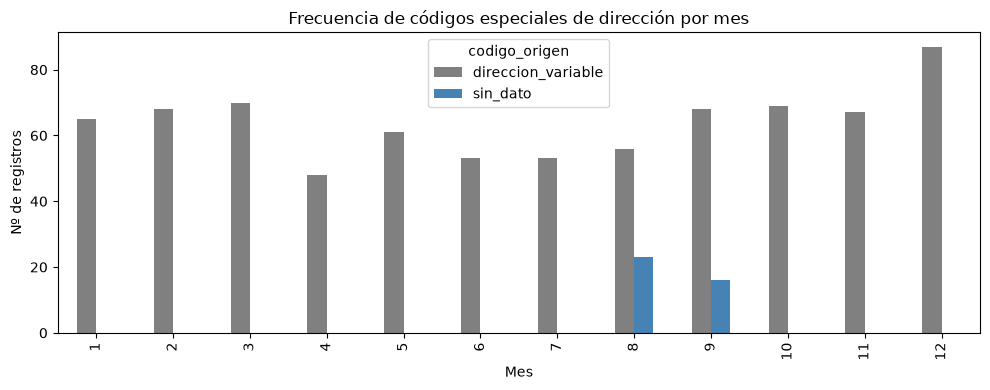

In [103]:
df["codigo_origen"] = pd.NA
mask_dir = df["variable_meteo"] == "viento_direccion"

for cod, etiqueta in CODIGOS_ESPECIALES_DIRECCION.items():
    m = mask_dir & (df["valor"] == cod)
    df.loc[m, "codigo_origen"] = etiqueta
    print(f"Código {cod} -> '{etiqueta}': {int(m.sum())} registros")

# --- Comprobación de que la asignación es la correcta -------------------------
# Si 99 fuese "calma", esos días tendrían viento nulo. Veamos si es así.
anc_v = (df.pivot_table(index=["estacion_nombre", "fecha"], columns="variable_meteo",
                        values="valor", aggfunc="first").reset_index())
perfil_dir = []
for cod in list(CODIGOS_ESPECIALES_DIRECCION) + ["normal"]:
    if cod == "normal":
        sel = anc_v["viento_direccion"].between(1, 36)
        etiqueta = "1-36 (ángulo real)"
    else:
        sel = anc_v["viento_direccion"] == cod
        etiqueta = f"{cod} ({CODIGOS_ESPECIALES_DIRECCION[cod]})"
    sub = anc_v[sel]
    if len(sub) == 0:
        continue
    perfil_dir.append({"código": etiqueta, "n_días": len(sub),
                       "velmedia_media": round(sub["viento_velocidad"].mean(), 2),
                       "velmedia_max": round(sub["viento_velocidad"].max(), 2),
                       "racha_max": round(sub["viento_racha"].max(), 2)})
display(pd.DataFrame(perfil_dir))

n_calma_real = int((anc_v["viento_velocidad"] == 0).sum())
print(f"Días con velmedia = 0 en TODO el dataset: {n_calma_real}")
print(f"Días marcados con el código 99: {int((anc_v['viento_direccion'] == 99).sum())}")
print("Si 99 significase 'calma', estas dos cifras deberían parecerse. No lo hacen:")
print("el código 99 es DIRECCIÓN VARIABLE, tal y como dicen los metadatos de AEMET.\n")

# El 88 es ausencia de dato: se anula el valor, no se guarda como categoría útil
m88 = mask_dir & df["valor"].isin(CODIGOS_DIRECCION_QUE_SON_AUSENCIA)
print(f"Registros con 88 (sin dato) que pasan a nulo: {int(m88.sum())}")
sub88 = df[m88]
if len(sub88):
    print("  estaciones:", sorted(sub88["estacion_nombre"].unique()))
    print("  rango de fechas:", sub88["fecha"].min().date(), "->", sub88["fecha"].max().date())
    print("  -> avería del sensor de dirección, no un fenómeno meteorológico.")
df.loc[m88, "valor"] = np.nan

df_an = df[~df["estacion_nombre"].isin(ESTACIONES_EXCLUIDAS)].copy()

dir_limpia = df_an[mask_dir.reindex(df_an.index, fill_value=False) & df_an["codigo_origen"].isna()]
print("\nEstadísticos de dirección SIN códigos especiales:")
display(dir_limpia["valor"].describe().round(2))

# ¿Son estacionales los códigos especiales? Si lo son, son señal, no ruido.
especiales_mes = (
    df_an[df_an["codigo_origen"].notna()]
    .groupby(["mes", "codigo_origen"]).size().unstack(fill_value=0)
)
display(especiales_mes)

if len(especiales_mes):
    ax = especiales_mes.plot(kind="bar", figsize=(10, 4), color=["grey", "steelblue"])
    ax.set_title("Frecuencia de códigos especiales de dirección por mes")
    ax.set_xlabel("Mes"); ax.set_ylabel("Nº de registros")
    plt.tight_layout(); plt.show()

## 3.7. Criterio final de outliers

| Filtro | Fiabilidad | Uso |
|---|---|---|
| IQR global | Baja | Solo orientativo; inservible para `precipitacion` (zero-inflated) |
| IQR mensual | Media | Detecta anomalías estacionales que el global esconde |
| Rango físico | Alta | Descarte duro: fuera de rango = error de dato |
| Coherencia interna | Muy alta | Un `temp_min > temp_max` es error seguro |
| Racha constante | Alta | Detecta sensores averiados que ningún filtro de valor pilla |

**Decisión:** solo se marca como error un valor que incumpla **rango físico**, **coherencia** o
**racha constante**. Lo que solo incumple el IQR se conserva.

**Importante para el TFM:** no se aplica winsorización ni recorte a los extremos climáticos
(−13,4 °C de Filomena, los 91 mm de la DANA, los 42,7 °C del verano de 2022). Son eventos reales
y son justamente la señal que explica los picos de contaminación. Recortarlos destruiría lo que
queremos medir.

# 4. Estacionalidad y eventos extremos

## 4.1. Medias mensuales y anuales

In [104]:
display(df_an.groupby(["variable_meteo", "mes"])["valor"].mean().unstack().round(2))
display(df_an.groupby(["variable_meteo", "anio"])["valor"].mean().unstack().round(2))

mes,1,2,3,4,5,6,7,8,9,10,11,12
variable_meteo,,,,,,,,,,,,
humedad_max,90.84,85.83,85.57,81.84,76.03,72.17,55.80,57.67,77.91,85.76,94.14,94.23
humedad_media,73.01,64.66,62.20,55.04,45.34,42.39,30.11,33.02,51.69,63.36,75.75,77.27
humedad_min,53.93,44.72,43.09,36.44,28.83,26.28,17.23,19.05,33.67,43.89,56.50,60.10
insolacion,5.59,6.48,5.93,7.94,9.91,10.38,12.32,11.26,8.29,6.37,5.34,4.74
precipitacion,0.98,0.52,1.57,1.54,1.00,0.73,0.11,0.46,1.87,2.62,1.29,1.36
presion_max,950.90,950.73,945.47,943.93,944.72,943.81,944.55,944.00,945.14,946.63,947.74,948.84
presion_min,946.29,945.75,940.64,939.44,940.53,939.79,940.72,940.08,941.37,942.14,943.53,944.08
temp_max,11.04,14.96,16.43,20.28,25.55,29.85,35.48,34.61,26.88,21.95,15.50,12.18
temp_media,6.42,9.55,11.20,14.27,18.85,23.17,27.90,27.40,21.03,16.66,11.12,7.95


anio,2020,2021,2022,2023,2024
variable_meteo,,,,,
humedad_max,78.58,81.32,78.31,78.71,81.38
humedad_media,57.12,56.59,54.63,54.92,57.23
humedad_min,40.01,38.56,37.79,37.12,38.90
insolacion,7.61,7.86,7.82,8.32,7.95
precipitacion,1.14,1.30,1.19,1.24,0.96
presion_max,946.71,945.91,946.57,946.59,945.99
presion_min,942.31,941.62,942.27,942.36,941.51
temp_max,21.67,21.25,22.79,22.46,22.37
temp_media,16.07,15.55,16.98,16.54,16.55


## 4.2. Heatmap de precipitación 
se calcula el acumulado mensual **por estación**, se descartan los meses en que
esa estación no llega al 90 % de días con dato, y se promedia entre las estaciones que quedan.
Se acompaña de la matriz de cuántas estaciones sostienen cada celda.

Un mes con 28 de 31 días acumularía un 10 % menos que uno completo, así que las sumas se
reescalan por `dias_mes / dias_con_dato` antes de compararlas. Las medias (temperatura) no lo
necesitan.

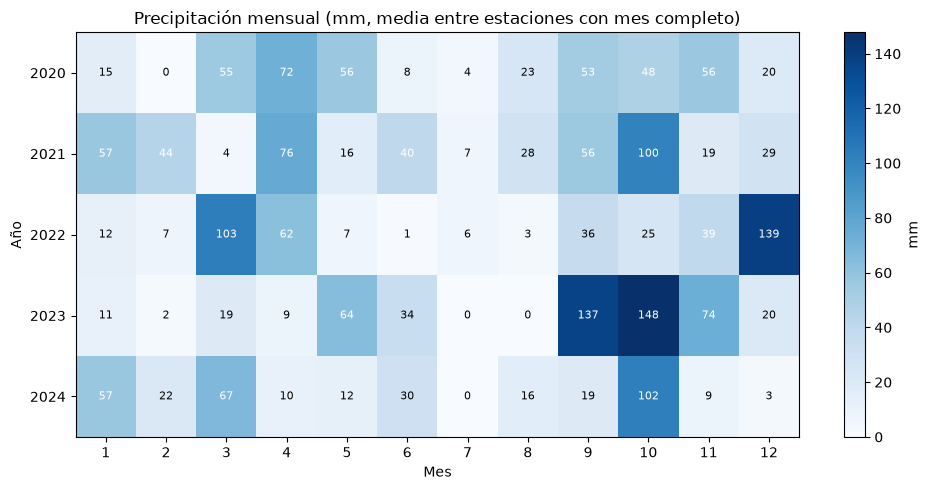

Nº de estaciones que sostienen cada celda:


mes,1,2,3,4,5,6,7,8,9,10,11,12
anio,,,,,,,,,,,,
2020,4,4,4,4,4,4,4,4,4,4,3,4
2021,4,4,4,4,4,3,4,4,4,4,4,3
2022,4,4,3,3,4,4,4,3,4,4,4,4
2023,4,4,4,4,4,4,4,4,3,3,2,4
2024,4,2,4,4,2,4,4,4,4,4,3,3


In [105]:
def agregado_mensual(datos, variable, funcion="sum", umbral=UMBRAL_MES_COMPLETO):
    sub = datos[datos["variable_meteo"] == variable].copy()
    dias_calendario = (
        pd.Series(CALENDARIO).dt.to_period("M").value_counts().sort_index()
        .rename_axis("periodo").rename("dias_mes")
    )
    sub["periodo"] = sub["fecha"].dt.to_period("M")
    g = sub.groupby(["estacion_nombre", "periodo"]).agg(
        valor=("valor", funcion), dias=("fecha", "nunique")).reset_index()
    g = g.merge(dias_calendario, on="periodo")
    g["completo"] = g["dias"] / g["dias_mes"] >= umbral
    validos = g[g["completo"]].copy()
    # Un acumulado sobre 28 de 31 días no es comparable con uno de mes completo:
    # se reescala. Las medias no lo necesitan.
    if funcion == "sum":
        validos["valor"] = validos["valor"] * validos["dias_mes"] / validos["dias"]
    matriz = validos.pivot_table(index=validos["periodo"].dt.year,
                                 columns=validos["periodo"].dt.month,
                                 values="valor", aggfunc="mean")
    soporte = validos.pivot_table(index=validos["periodo"].dt.year,
                                  columns=validos["periodo"].dt.month,
                                  values="estacion_nombre", aggfunc="nunique")
    matriz.index.name = "anio"; matriz.columns.name = "mes"
    soporte.index.name = "anio"; soporte.columns.name = "mes"
    return matriz.round(1), soporte


def heatmap(matriz, titulo, cmap, fmt="{:.0f}", unidad=""):
    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(matriz.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(matriz.columns))); ax.set_xticklabels(matriz.columns)
    ax.set_yticks(range(len(matriz.index)));   ax.set_yticklabels(matriz.index)
    ax.set_xlabel("Mes"); ax.set_ylabel("Año"); ax.set_title(titulo)
    fig.colorbar(im, ax=ax, label=unidad)
    media = np.nanmean(matriz.values)
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            v = matriz.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8,
                        color="white" if v > media else "black")
    plt.tight_layout(); plt.show()


prec_mes, prec_soporte = agregado_mensual(df_an, "precipitacion", "sum")
heatmap(prec_mes, "Precipitación mensual (mm, media entre estaciones con mes completo)",
        "Blues", "{:.0f}", "mm")
print("Nº de estaciones que sostienen cada celda:")
display(prec_soporte.fillna(0).astype(int))

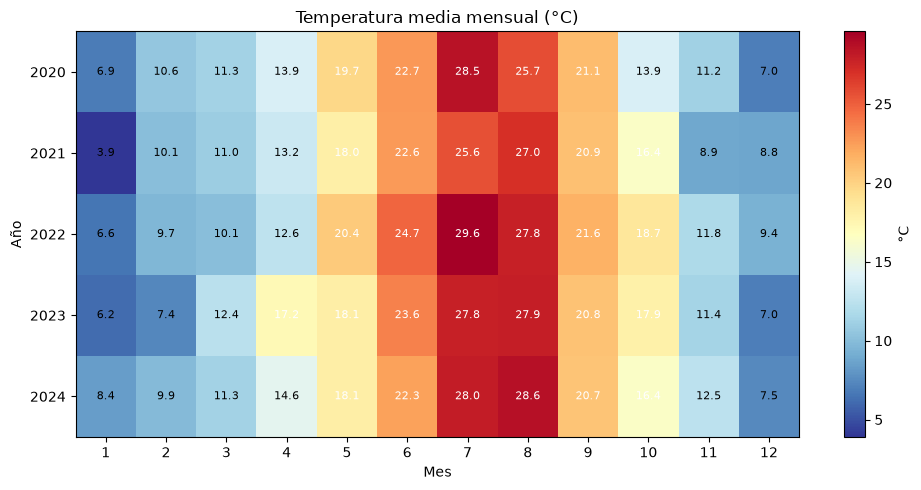

In [106]:
temp_mes, _ = agregado_mensual(df_an, "temp_media", "mean")
heatmap(temp_mes, "Temperatura media mensual (°C)", "RdYlBu_r", "{:.1f}", "°C")

## 4.3. Eventos extremos: verificación

Comprobamos que los eventos conocidos aparecen en los datos. Sirve de validación de que el
pipeline no ha roto nada: si Filomena no sale, es que algo está mal.

In [107]:
eventos = {
    "Filomena (nevada)":        ("2021-01-06", "2021-01-12"),
    "Ola de calor jul-2022":    ("2022-07-09", "2022-07-20"),
    "DANA + Aline (sep-oct 23)":("2023-09-01", "2023-10-25"),
    "DANA oct-2024":            ("2024-10-28", "2024-11-05"),
}

for nombre, (ini, fin) in eventos.items():
    sub = df_an[(df_an["fecha"] >= ini) & (df_an["fecha"] <= fin)]
    print(f"\n=== {nombre} ({ini} a {fin}) ===")
    resumen = sub[sub["variable_meteo"].isin(["temp_min", "temp_max", "precipitacion"])] \
        .groupby(["variable_meteo", "estacion_nombre"])["valor"] \
        .agg(["min", "max", "sum", "count"]).round(1)
    display(resumen)


=== Filomena (nevada) (2021-01-06 a 2021-01-12) ===


min   max   sum  count
variable_meteo estacion_nombre                                
precipitacion  GETAFE                   0.0  30.8  39.8      7
               MADRID AEROPUERTO        0.0  21.2  38.1      7
               MADRID, CUATRO VIENTOS   0.0  19.1  32.7      7
               MADRID, RETIRO           0.0  32.9  52.9      7
temp_max       GETAFE                   0.0   6.6  18.8      7
               MADRID AEROPUERTO        0.3   7.1  21.2      7
               MADRID, CUATRO VIENTOS   0.0   7.0  22.1      7
               MADRID, RETIRO           0.3   5.0  14.3      7
temp_min       GETAFE                 -12.0  -0.6 -32.6      7
               MADRID AEROPUERTO      -13.4  -1.3 -43.9      7
               MADRID, CUATRO VIENTOS -13.0  -0.4 -27.5      7
               MADRID, RETIRO          -7.4  -0.6 -18.0      7


=== Ola de calor jul-2022 (2022-07-09 a 2022-07-20) ===


min   max    sum  count
variable_meteo estacion_nombre                                 
precipitacion  GETAFE                   0.0   0.0    0.0     12
               MADRID AEROPUERTO        0.0   0.0    0.0     12
               MADRID, CUATRO VIENTOS   0.0   0.0    0.0     12
               MADRID, RETIRO           0.0   0.0    0.0     12
temp_max       GETAFE                  34.4  42.0  470.4     12
               MADRID AEROPUERTO       35.0  42.2  471.3     12
               MADRID, CUATRO VIENTOS  34.2  41.5  466.5     12
               MADRID, RETIRO          36.6  40.7  384.8     10
temp_min       GETAFE                  21.2  26.6  292.6     12
               MADRID AEROPUERTO       18.3  23.4  257.9     12
               MADRID, CUATRO VIENTOS  20.3  27.4  288.8     12
               MADRID, RETIRO          20.8  26.2  242.3     10


=== DANA + Aline (sep-oct 23) (2023-09-01 a 2023-10-25) ===


min   max     sum  count
variable_meteo estacion_nombre                                  
precipitacion  GETAFE                   0.0  78.1   253.2     52
               MADRID AEROPUERTO        0.0  73.8   286.8     55
               MADRID, CUATRO VIENTOS   0.0  91.2   261.6     55
temp_max       GETAFE                  15.0  32.6  1428.5     55
               MADRID AEROPUERTO       14.9  33.2  1428.0     55
               MADRID, CUATRO VIENTOS  14.4  32.2  1398.0     55
               MADRID, RETIRO          13.2  31.6  1344.0     55
temp_min       GETAFE                   7.6  20.0   832.9     55
               MADRID AEROPUERTO        7.7  20.1   739.8     55
               MADRID, CUATRO VIENTOS   6.6  20.0   791.7     55
               MADRID, RETIRO           7.8  20.3   842.9     55


=== DANA oct-2024 (2024-10-28 a 2024-11-05) ===


min   max    sum  count
variable_meteo estacion_nombre                                 
precipitacion  GETAFE                   0.0  20.0   33.9      9
               MADRID AEROPUERTO        0.0  26.3   37.2      9
               MADRID, CUATRO VIENTOS   0.0  23.1   32.6      9
               MADRID, RETIRO           0.0  29.7   36.7      9
temp_max       GETAFE                  16.5  20.6  173.9      9
               MADRID AEROPUERTO       16.3  21.8  174.6      9
               MADRID, CUATRO VIENTOS  16.4  20.5  172.1      9
               MADRID, RETIRO          15.7  19.5  162.7      9
temp_min       GETAFE                   8.8  13.4   99.5      9
               MADRID AEROPUERTO        9.5  12.7   90.9      9
               MADRID, CUATRO VIENTOS   8.5  13.0   96.1      9
               MADRID, RETIRO           9.1  13.3  103.0      9

# 5. Relación entre estaciones e imputación validada

Antes de imputar nada hay que demostrar que las estaciones se parecen lo suficiente. Y después,
**medir el error de la imputación**, no solo afirmar que la correlación es alta.

## 5.1. Correlación entre estaciones, variable a variable

In [108]:
for var in VARIABLES_CLAVE:
    piv = df_an[df_an["variable_meteo"] == var].pivot_table(
        index="fecha", columns="estacion_nombre", values="valor")
    print(f"\n=== {var} — correlación entre estaciones (r de Pearson) ===")
    display(piv.corr().round(3))


=== precipitacion — correlación entre estaciones (r de Pearson) ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CUATRO VIENTOS","MADRID, RETIRO"
estacion_nombre,,,,
GETAFE,1.000,0.868,0.943,0.872
MADRID AEROPUERTO,0.868,1.000,0.896,0.842
"MADRID, CUATRO VIENTOS",0.943,0.896,1.000,0.867
"MADRID, RETIRO",0.872,0.842,0.867,1.000



=== temp_media — correlación entre estaciones (r de Pearson) ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CUATRO VIENTOS","MADRID, RETIRO"
estacion_nombre,,,,
GETAFE,1.000,0.994,0.997,0.997
MADRID AEROPUERTO,0.994,1.000,0.992,0.993
"MADRID, CUATRO VIENTOS",0.997,0.992,1.000,0.998
"MADRID, RETIRO",0.997,0.993,0.998,1.000



=== viento_velocidad — correlación entre estaciones (r de Pearson) ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CUATRO VIENTOS","MADRID, RETIRO"
estacion_nombre,,,,
GETAFE,1.000,0.842,0.903,0.843
MADRID AEROPUERTO,0.842,1.000,0.849,0.806
"MADRID, CUATRO VIENTOS",0.903,0.849,1.000,0.798
"MADRID, RETIRO",0.843,0.806,0.798,1.000



=== humedad_media — correlación entre estaciones (r de Pearson) ===


estacion_nombre,GETAFE,MADRID AEROPUERTO,"MADRID, CUATRO VIENTOS","MADRID, RETIRO"
estacion_nombre,,,,
GETAFE,1.000,0.972,0.968,0.959
MADRID AEROPUERTO,0.972,1.000,0.969,0.959
"MADRID, CUATRO VIENTOS",0.968,0.969,1.000,0.970
"MADRID, RETIRO",0.959,0.959,0.970,1.000


## 5.2. Imputación del hueco de viento de Retiro: cuatro métodos comparados

Se entrena con los días en que las estaciones tienen dato **antes** de una fecha de corte, se
predice sobre el tramo posterior (que sí tiene dato real) y se mide el error. Solo así se puede
justificar el método elegido, y de paso se puede reportar el error de la imputación en la
memoria.

La donante no se elige por proximidad geográfica sino **por correlación**, y se compara también
una regresión múltiple que usa las tres donantes a la vez.

Todos los métodos se evalúan **sobre el mismo conjunto de días** (aquellos en los que las cuatro
estaciones tienen dato), para que los RMSE sean comparables entre sí.

**Interpretación de la pendiente.** Sale muy por debajo de 1 porque Retiro es un anemómetro en
parque urbano, resguardado por arbolado, mientras que Getafe y Cuatro Vientos son bases aéreas
con exposición abierta. Esa pendiente *es* el factor de abrigo, y es exactamente la razón por la
que la copia directa no vale: arrastra un sesgo sistemático de casi 1 m/s.

In [109]:
EST_DESTINO = "MADRID, RETIRO"
VAR_IMPUTAR = "viento_velocidad"
FECHA_CORTE = "2023-07-01"   # entrenamiento antes, validación después

piv = (df_an[df_an["variable_meteo"] == VAR_IMPUTAR]
       .pivot_table(index="fecha", columns="estacion_nombre", values="valor"))

# --- Elección de la donante por correlación, no a ojo -------------------------
ranking = (piv.corr()[EST_DESTINO].drop(EST_DESTINO)
           .sort_values(ascending=False).round(3).rename("r con " + EST_DESTINO))
print("Correlación de cada donante con el destino:")
display(ranking.to_frame())

EST_ORIGEN = ranking.index[0]
print(f"Donante elegida: {EST_ORIGEN}  (r = {ranking.iloc[0]:.3f})")
if len(ranking) > 1:
    print(f"Segunda opción : {ranking.index[1]}  (r = {ranking.iloc[1]:.3f})")

DONANTES = list(ranking.index)

# Días con dato en las cuatro estaciones: base común de comparación
M = piv[[EST_DESTINO] + DONANTES].dropna()
pareja = M[[EST_DESTINO, EST_ORIGEN]].copy()
pareja.columns = ["destino", "origen"]
pareja["mes"] = pareja.index.month

train = pareja[pareja.index < FECHA_CORTE]
test  = pareja[pareja.index >= FECHA_CORTE]
M_train, M_test = M.loc[train.index], M.loc[test.index]

print(f"\nDías con las {len(DONANTES) + 1} estaciones a la vez: {len(M)}"
      f"  |  train: {len(train)}  |  test: {len(test)}")
print(f"r global (destino vs donante elegida): {pareja['destino'].corr(pareja['origen']):.3f}")
print(f"Sesgo medio (destino - origen): {(pareja['destino'] - pareja['origen']).mean():.2f} m/s")


Correlación de cada donante con el destino:


,"r con MADRID, RETIRO"
estacion_nombre,
GETAFE,0.843
MADRID AEROPUERTO,0.806
"MADRID, CUATRO VIENTOS",0.798


Donante elegida: GETAFE  (r = 0.843)
Segunda opción : MADRID AEROPUERTO  (r = 0.806)

Días con las 4 estaciones a la vez: 1234  |  train: 687  |  test: 547
r global (destino vs donante elegida): 0.843
Sesgo medio (destino - origen): -1.31 m/s


In [110]:
def metricas(real, pred, nombre):
    e = pred - real
    return {"metodo": nombre,
            "MAE": round(np.abs(e).mean(), 3),
            "RMSE": round(np.sqrt((e ** 2).mean()), 3),
            "sesgo": round(e.mean(), 3),
            "r": round(np.corrcoef(real, pred)[0, 1], 3)}


resultados = []
preds_test, preds_train = {}, {}   # predicciones por método (train/test)


def registrar(nombre, p_train, p_test):
    preds_train[nombre] = p_train
    preds_test[nombre] = p_test
    resultados.append(metricas(test["destino"], p_test, nombre))


# Método 1: copiar el valor de la estación origen tal cual
registrar("1. Copia directa", train["origen"], test["origen"])

# Método 2: origen + corrección de sesgo mensual
offset = (train["destino"] - train["origen"]).groupby(train["mes"]).mean()
registrar("2. Offset mensual",
          train["origen"] + train["mes"].map(offset),
          test["origen"] + test["mes"].map(offset))

# Método 3: regresión lineal simple destino ~ origen
b, a = np.polyfit(train["origen"], train["destino"], 1)
NOMBRE_M3 = f"3. Regresión simple (y={a:.2f}+{b:.2f}x)"
registrar(NOMBRE_M3, a + b * train["origen"], a + b * test["origen"])

# Método 4: regresión múltiple con las tres donantes a la vez
X_tr = np.c_[np.ones(len(M_train)), M_train[DONANTES].values]
X_te = np.c_[np.ones(len(M_test)),  M_test[DONANTES].values]
coef, *_ = np.linalg.lstsq(X_tr, M_train[EST_DESTINO].values, rcond=None)
NOMBRE_M4 = f"4. Regresión múltiple ({len(DONANTES)} donantes)"
registrar(NOMBRE_M4,
          pd.Series(X_tr @ coef, index=M_train.index),
          pd.Series(X_te @ coef, index=M_test.index))

print("Coeficientes de la regresión múltiple:")
for nombre, c in zip(["intercepto"] + DONANTES, coef):
    print(f"  {nombre:<28} {c:+.3f}")

comparativa = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
display(comparativa)

MEJOR_METODO = comparativa.iloc[0]["metodo"]
SIGMA_TEST = test["destino"].std()
print(f"\nMejor método por RMSE: {MEJOR_METODO}")
print(f"Desviación típica de la serie real en test: {SIGMA_TEST:.2f} m/s")
print("(un RMSE cercano a esta cifra significa que la imputación no aporta nada)")


Coeficientes de la regresión múltiple:
  intercepto                   +0.518
  GETAFE                       +0.293
  MADRID AEROPUERTO            +0.173
  MADRID, CUATRO VIENTOS       +0.009


,metodo,MAE,RMSE,sesgo,r
0,4. Regresión múltiple (3 donantes),0.344,0.450,-0.040,0.892
1,3. Regresión simple (y=0.63+0.43x),0.367,0.482,-0.031,0.875
2,2. Offset mensual,0.931,1.177,-0.083,0.866
3,1. Copia directa,1.332,1.720,1.271,0.875



Mejor método por RMSE: 4. Regresión múltiple (3 donantes)
Desviación típica de la serie real en test: 0.99 m/s
(un RMSE cercano a esta cifra significa que la imputación no aporta nada)


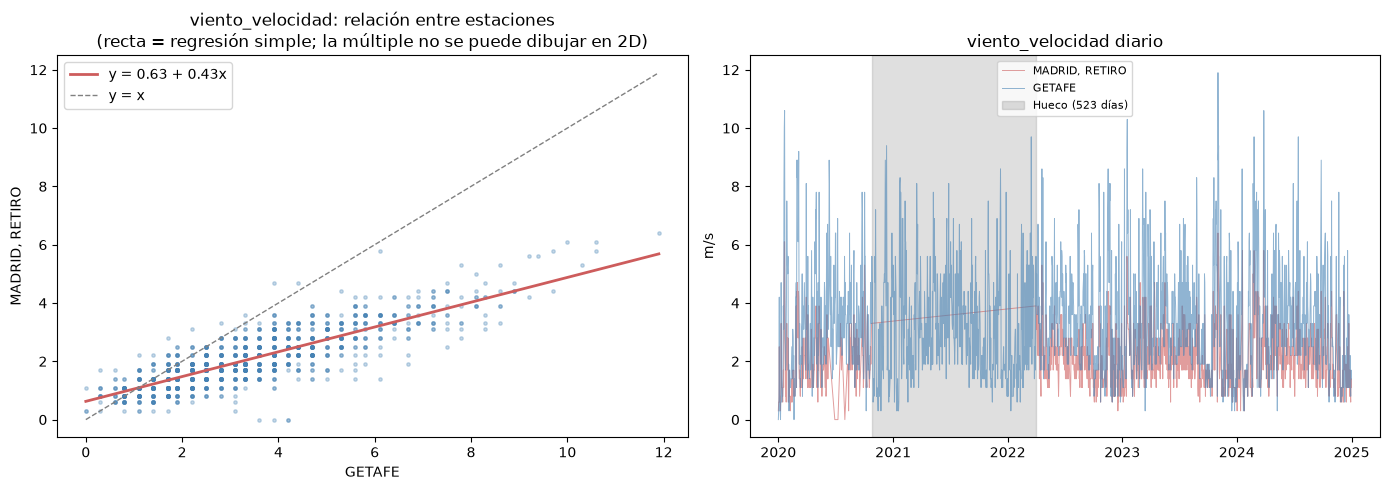

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pareja["origen"], pareja["destino"], s=6, alpha=0.3, color="steelblue")
x = np.linspace(pareja["origen"].min(), pareja["origen"].max(), 50)
axes[0].plot(x, a + b * x, color="indianred", lw=2, label=f"y = {a:.2f} + {b:.2f}x")
axes[0].plot(x, x, color="grey", ls="--", lw=1, label="y = x")
axes[0].set_xlabel(EST_ORIGEN); axes[0].set_ylabel(EST_DESTINO)
axes[0].set_title(f"{VAR_IMPUTAR}: relación entre estaciones\n"
                  f"(recta = regresión simple; la múltiple no se puede dibujar en 2D)")
axes[0].legend()

for est, color in [(EST_DESTINO, "indianred"), (EST_ORIGEN, "steelblue")]:
    s = piv[est].dropna()
    axes[1].plot(s.index, s.values, label=est, color=color, alpha=0.6, lw=0.7)
b_huecos = bloques_de_huecos(piv[EST_DESTINO].dropna().index)
if len(b_huecos):
    peor = b_huecos.loc[b_huecos["dias"].idxmax()]
    axes[1].axvspan(peor["inicio"], peor["fin"], color="grey", alpha=0.25,
                    label=f"Hueco ({int(peor['dias'])} días)")
axes[1].set_title(f"{VAR_IMPUTAR} diario"); axes[1].set_ylabel("m/s"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5.3. Rosa de las rachas máximas por estación

**Ojo con cómo se lee este gráfico.** El campo `dir` de AEMET es la *dirección de la racha
máxima* del día, no la dirección dominante del viento. Lo que sale aquí es, por tanto, una rosa
de **rachas máximas diarias**, no la rosa de vientos clásica. Es útil igual para comparar
régimen entre estaciones, pero hay que etiquetarla bien en la memoria y no interpretarla como
"de dónde sopla el viento en Madrid".

Si Retiro y Cuatro Vientos comparten régimen de direcciones, refuerza que una pueda sustituir a
la otra en la imputación de velocidad. Si las rosas son distintas, la imputación es más
discutible aunque la correlación sea alta.

Los días con código `99` (dirección variable) quedan fuera del gráfico, que es lo correcto: no
tienen un ángulo que representar.

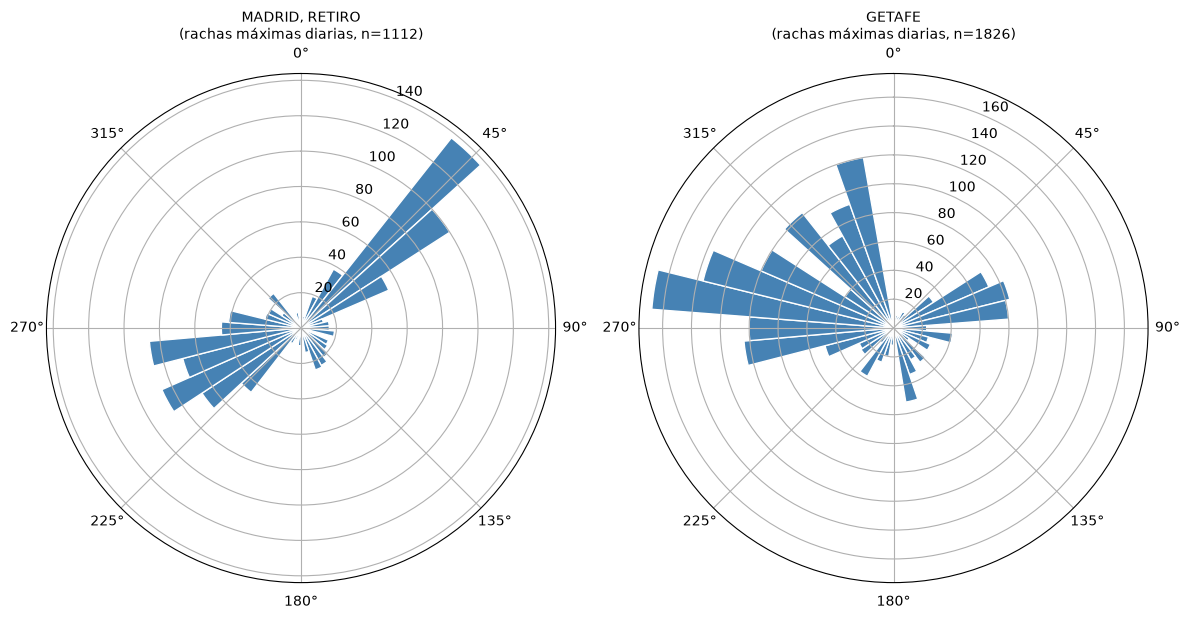

In [112]:
dir_ok = df_an[(df_an["variable_meteo"] == "viento_direccion") & (df_an["codigo_origen"].isna())]
ests = [e for e in [EST_DESTINO, EST_ORIGEN] if e in dir_ok["estacion_nombre"].unique()]

fig, axes = plt.subplots(1, len(ests), figsize=(6 * len(ests), 6),
                         subplot_kw={"projection": "polar"}, squeeze=False)
for ax, est in zip(axes[0], ests):
    sub = dir_ok[dir_ok["estacion_nombre"] == est]
    ax.hist(np.deg2rad(sub["valor"] * 10), bins=36, color="steelblue", edgecolor="white")
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_title(f"{est}\n(rachas máximas diarias, n={len(sub)})", fontsize=10)
plt.tight_layout(); plt.show()

# 6. Correlación entre variables y selección

Con la tabla en formato ancho podemos ver qué variables aportan información nueva y cuáles son
redundantes. Es la base para decidir qué se lleva al modelo de calidad del aire.

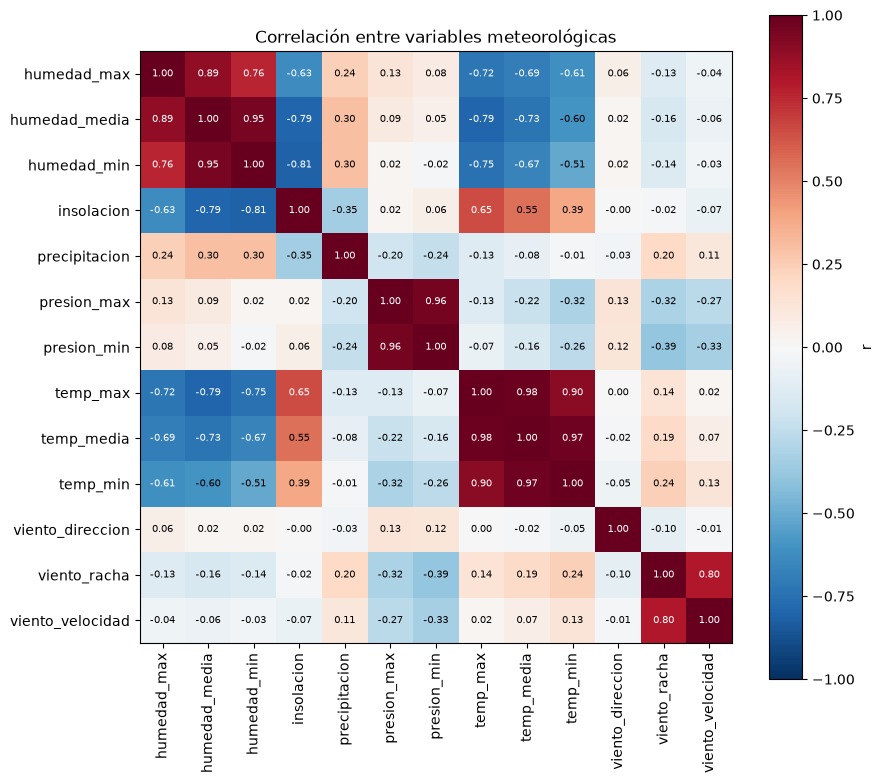

Pares con |r| > 0.90 (redundantes):


variable_meteo  variable_meteo
temp_max        temp_media        0.98
temp_media      temp_min          0.97
presion_max     presion_min       0.96
humedad_media   humedad_min       0.95
dtype: float64

In [113]:
cols_num = [v for v in VARIABLES if v in ancho_an.columns]
corr = ancho_an[cols_num].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_num))); ax.set_xticklabels(cols_num, rotation=90)
ax.set_yticks(range(len(cols_num))); ax.set_yticklabels(cols_num)
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, label="r")
ax.set_title("Correlación entre variables meteorológicas")
plt.tight_layout(); plt.show()

# Pares muy redundantes (candidatos a quedarse solo con uno)
pares = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pares = pares[pares > 0.9].sort_values(ascending=False)
print("Pares con |r| > 0.90 (redundantes):")
display(pares.round(3))

# 7. Resumen de tratamiento por variable

| Variable | Situación | Tratamiento |
|---|---|---|
| `precipitacion` | Ventana **07-07 UTC** (de D a D+1), distinta del resto de variables. 95,5 % sin CU. Retiro sin dato ago–nov 2023 (84 días, coincide en fechas con la DANA). 237 días `Ip` descartados por la conversión JSON→CSV | Recuperar `Ip` como **0,0 mm** con `codigo_origen='Ip'`. Documentar y **no imputar** el tramo de Retiro. Añadir binaria "día de lluvia" (≥ 0,1 mm) y acumulados móviles |
| `temp_media/min/max` | 99,7 % sin CU. Sin outliers de rango | Interpolación temporal para huecos ≤ 5 días. Usable |
| `humedad_media` | 99,3 % | Usable |
| `humedad_max/min` | Getafe solo 44 días de 1.827 | Descartar el par (Getafe, humedad_max/min). En las otras tres estaciones, usable |
| `presion_max/min` | 99,4 %. Rango correcto como presión de estación | Usable. Muy correlacionadas entre sí: quedarse con una o con la media |
| `insolacion` | **Sin ningún registro** en Retiro; ~99 % en las otras tres | Descartar el par (Retiro, insolacion) |
| `viento_velocidad/racha` | Retiro sin dato 523 días (oct 2020 – mar 2022) | Imputar desde la donante mejor correlacionada con el método ganador de 5.2, con `flag_imputado`. Si el RMSE no baja claramente de la σ de la serie, documentar y excluir |
| `viento_direccion` | Es la **dirección de la racha máxima**, no la dominante. 774 códigos `99` = dirección variable; 39 códigos `88` = **sin dato** (todos de Retiro, ago-sep 2020: avería del sensor) | Renombrar a `direccion_racha_max`. Ángulo 1–36 en `valor`; `99` a `codigo_origen`; `88` a nulo. Para modelar: seno/coseno, nunca el ángulo crudo |
| **Ciudad Universitaria** | Serie partida: temperatura muere en may-2021 (hueco de 1.330 días), viento inexistente 2020–2022, y `presion_max`, `presion_min` e `insolacion` **sin ningún registro** en todo el periodo | **Excluir la estación completa** |

**Nota sobre el tramo de precipitación de Retiro.** Que falte solo `prec` mientras la
temperatura del mismo día sí está, y que el hueco arranque el 31-08-2023, es coherente con un
pluviómetro averiado durante el episodio. Es la hipótesis más razonable y justifica no imputar,
pero **es una inferencia, no un hecho verificado**: en la memoria conviene redactarlo como tal.
Su consecuencia práctica es que cualquier acumulado de otoño de 2023 que incluya Retiro queda
sesgado a la baja, y por eso los agregados mensuales exigen el 90 % de días con dato.

# 8. Instrucciones para el pipeline

Separadas en dos capas porque son responsabilidades distintas: la capa normalizada debe ser
**fiel al origen** (no borra, marca), y las decisiones de análisis van después.

## A. Capa de normalización

- **A1.** En `descarga_aemt.py` (JSON -> CSV): `Ip` -> valor `0.0` con `codigo_origen="Ip"`.
  **No descartar la fila.** Confirmado contra los JSON crudos. No existe `Acum` en este periodo.
  El 0.0 (y no 0,05) evita meter milímetros ficticios en los acumulados. (Poner los vacios como 0.0)
- **A2.** Añadir al hecho `codigo_origen` (texto), `flag_imputado` (bool) y
  `metodo_imputacion` (texto). Genéricas, no específicas de una variable.
- **A3.** Separar `dim_estacion` (id, nombre, provincia, altitud, **latitud**, **longitud**)
  del hecho, que se queda con `estacion_id`. `provincia` es constante en todas las filas.
- **A4.** Incorporar latitud y longitud de cada estación desde `inventarioestaciones` de AEMET
  OpenData: imprescindibles para cruzar cada estación de calidad del aire con su estación meteo
  más cercana.
- **A5.** `viento_direccion`: **`99` = dirección variable** (`valor` a nulo, etiqueta a
  `codigo_origen`) y **`88` = sin dato** (`valor` a nulo, es un hueco). El campo es la
  *dirección de la racha máxima*: renombrarlo a `direccion_racha_max` y corregir la descripción
  de `dim_variable`, que dice "Dirección del viento dominante".
- **A6.** Rango físico y coherencia interna (`temp_min <= temp_media <= temp_max`, etc.):
  marcar en `flag_calidad`, **no borrar** (los extremos climáticos son datos reales, ver B6).
- **A7.** **Día pluviométrico: ventana 07-07 UTC.** Los metadatos de AEMET definen `prec` como
  *"Precipitación diaria de 07 a 07"*: la ventana va de las 07:00 UTC del día de la fecha a las
  07:00 UTC del día siguiente. El resto de variables usan el día natural. Corregir la
  descripción de `precipitacion` (hoy dice "Precipitación acumulada diaria") y, al cruzar con
  la calidad del aire horaria, agregar la contaminación en esa misma ventana 07-07 o documentar
  el desfase de +7 h.

## B. Capa analítica

- **B1.** Excluir Ciudad Universitaria (3194U) completa.
- **B2.** Excluir los pares (Getafe, `humedad_max`), (Getafe, `humedad_min`),
  (Retiro, `insolacion`).
- **B3.** Interpolar temporalmente los huecos de <= 5 días, marcando `flag_imputado`.
- **B4.** Imputar `viento_velocidad` de Retiro (523 días sin dato, oct 2020 – mar 2022) por
  **regresión lineal múltiple** sobre las tres estaciones donantes:
  `Retiro = 0.518 + 0.293·Getafe + 0.173·Aeropuerto + 0.009·Cuatro Vientos`. Es el mejor de
  los cuatro métodos comparados: **RMSE 0,45 m/s** frente a una σ de la serie de 0,99 m/s
  (RMSE/σ ≈ 0,45, muy por debajo del 0,75 a partir del cual no compensaría imputar). Marcar el
  tramo con `flag_imputado=True` y `metodo_imputacion="regresion_multiple"`. Queda descartada
  la copia directa desde una sola estación: arrastra un sesgo de +1,3 m/s porque Retiro está
  abrigado por el arbolado del parque. El tramo imputado **no debe usarse para estimar extremos
  ni rachas de viento** (la regresión encoge la varianza). Requisito: las tres donantes deben
  tener dato todos los días a rellenar; si algún día falta una, aplicar una regla de reserva
  con las que sí lo tengan. `viento_racha` comparte el mismo hueco: imputar con la misma
  técnica solo si va a entrar en el modelo; si no, dejarlo sin imputar y marcarlo.
- **B5.** No imputar el tramo de `precipitacion` de Retiro (ago-nov 2023): documentarlo.
- **B6.** No winsorizar ni recortar los extremos climáticos.
